# Libraries and Data Information

## Installations

### Mount Google Drive

In [1]:
from google.colab import drive, files, runtime
drive.mount('/content/drive')

Mounted at /content/drive


### Check for Nvidia GPU.

In [2]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


### Create Virtual Environment

In [3]:
#!python -m venv /content/drive/My Drive/my_env  # Store in your Drive

### Activate Environment

In [4]:
!source /content/drive/My Drive/my_env/bin/activate

/bin/bash: line 1: /content/drive/My: No such file or directory


## Install Packages.

In [5]:
!pip install numpy  # Install or upgrade NumPy first
!pip install scipy==1.10.0 # Install scipy specifically version 1.10.0
!pip install scikit-learn  # Install scikit-learn
!pip install tensorflow  # Install TensorFlow
!pip install torch  # Install PyTorch

ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires-Python >=3.8,<3.12; 1.9.1 Requires-Python >=3.8,<3.12
ERROR: Could not find a version that satisfies the requirement scipy==1.10.0 (from versions:

In [6]:
!pip install numpy  # Install NumPy first
!pip install numpy.rec # Install numpy.rec specifically.
!pip install scipy==1.10.0 # Reinstall SciPy with the version you need.
#!pip install keras_spiking --upgrade # Install keras_spiking
!pip install keras_spiking # Install keras_spiking

ERROR: Could not find a version that satisfies the requirement numpy.rec (from versions: none)
ERROR: No matching distribution found for numpy.rec
ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires

## Libraries

In [7]:
#matplotlib imports
import matplotlib.pyplot as plt
import matplotlib.pyplot as scatter
import matplotlib.cm as cm
import time


from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

# keras/tensorflow imports
import tensorflow as tf
from tensorflow.python.keras.engine.base_layer import Layer
#from tensorflow.python.keras.layers.rnn.rnn import RNN
from keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU, Flatten, Conv1D
from keras.layers import MaxPooling1D, TimeDistributed, GlobalAveragePooling1D
from keras.models import Sequential
import keras_spiking
from keras_spiking import SpikingActivation

# warnings imports
import warnings
warnings.filterwarnings("ignore")


# torch imports
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device}" " is available.")

# Other imports
from urllib.request import urlretrieve
import collections
import numpy as np
import pandas as pd
from math import sqrt
import os
import pickle
from datetime import datetime, timedelta
from google.colab import drive

cpu is available.


# Load Data

In [8]:
data_to_load = files.upload()

Saving Sunspots.csv to Sunspots.csv


# Read and Check Data

## Preprocessing stage.

In [9]:
filename_list = list(data_to_load.keys())
filename = filename_list[0]

In [10]:
df_entire = pd.read_csv(filename)
df_entire.head()

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7


In [11]:
df_entire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265 entries, 0 to 3264
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         3265 non-null   int64  
 1   Date                               3265 non-null   object 
 2   Monthly Mean Total Sunspot Number  3265 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 76.7+ KB


## Other Pre-Processing Information

In [12]:
# We must convert the Datetime column to Datetime format
df_entire['Date'] = pd.to_datetime(df_entire['Date'])

# We index the Datetime column after transformation
df_entire.set_index('Date', inplace=True)
df_entire.head()

,Unnamed: 0,Monthly Mean Total Sunspot Number
Date,,
1749-01-31,0,96.7
1749-02-28,1,104.3
1749-03-31,2,116.7
1749-04-30,3,92.8
1749-05-31,4,141.7


In [13]:
# checking missing data
df_entire.isna().sum()

,0
Unnamed: 0,0
Monthly Mean Total Sunspot Number,0


In [14]:
# Let's look at the years in the data set
years = df_entire.index.year.unique()
years

Index([1749, 1750, 1751, 1752, 1753, 1754, 1755, 1756, 1757, 1758,
       ...
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021],
      dtype='int32', name='Date', length=273)

In [15]:
df_entire = df_entire.drop(columns = ['Unnamed: 0'])
df_entire

,Monthly Mean Total Sunspot Number
Date,
1749-01-31,96.7
1749-02-28,104.3
1749-03-31,116.7
1749-04-30,92.8
1749-05-31,141.7
...,...
2020-09-30,0.6
2020-10-31,14.4
2020-11-30,34.0


## Plot MMT based on Trends and Seasonality.

In [16]:
def plot_sunspot_num(select_df, start, end, seasonality, title_name, feature):
    plt.figure(figsize=(16, 16))
    plt.plot(select_df[start:end], label=feature)
    plt.locator_params(axis='x', nbins=10)
    plt.locator_params(axis='y', nbins=10)
    plt.rc('xtick', labelsize=15)
    plt.rc('ytick', labelsize=15)
    plt.ylabel(feature, fontsize = 20)
    plt.xlabel("Date", fontsize = 20)
    plt.title("{0} ({1})".format(title_name, seasonality), fontsize = 20)
    plt.show()

### Trend Plot

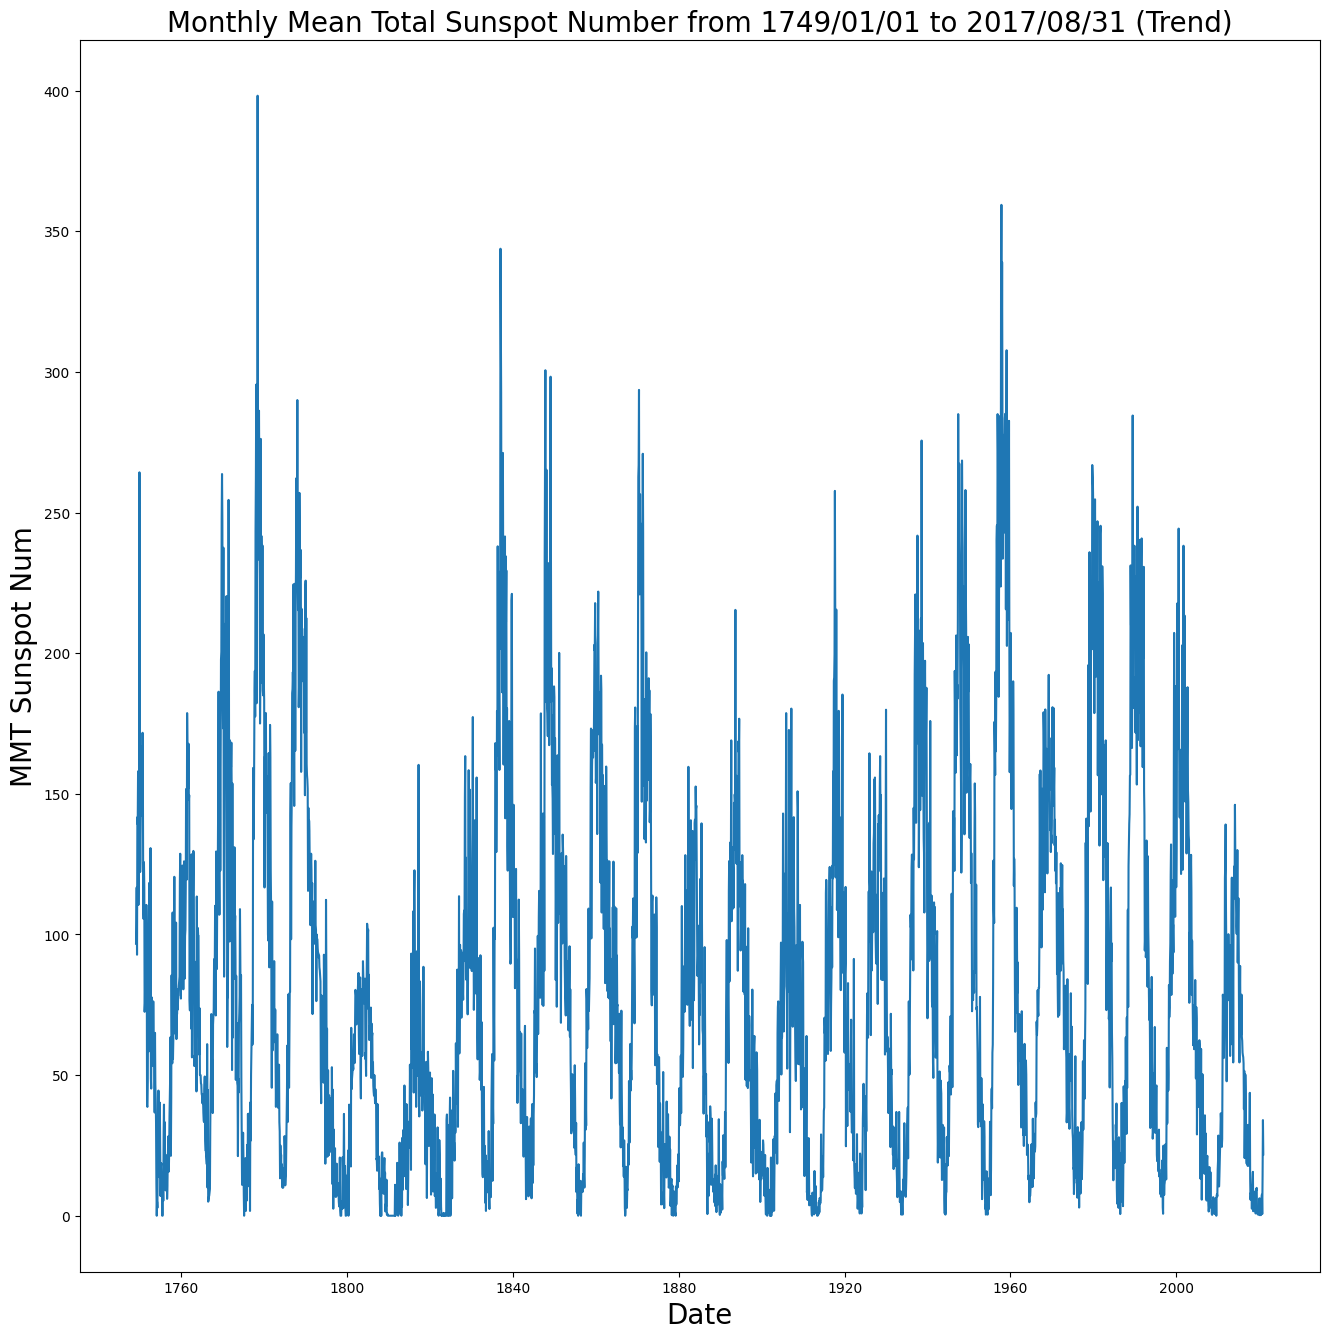

In [17]:
title_name = 'Monthly Mean Total Sunspot Number from 1749/01/01 to 2017/08/31'
plot_sunspot_num(df_entire, 0, df_entire.shape[0]-1, "Trend", title_name,
                 'MMT Sunspot Num')

### Yearly Plots (Seasonality)

In [18]:
yearly_df = df_entire.query("Date >= '2001-01-01' \
                       and Date <= '2002-01-01'")
yearly_df

,Monthly Mean Total Sunspot Number
Date,
2001-01-31,142.6
2001-02-28,121.5
2001-03-31,165.8
2001-04-30,161.7
2001-05-31,142.1
2001-06-30,202.9
2001-07-31,123.0
2001-08-31,161.5
2001-09-30,238.2


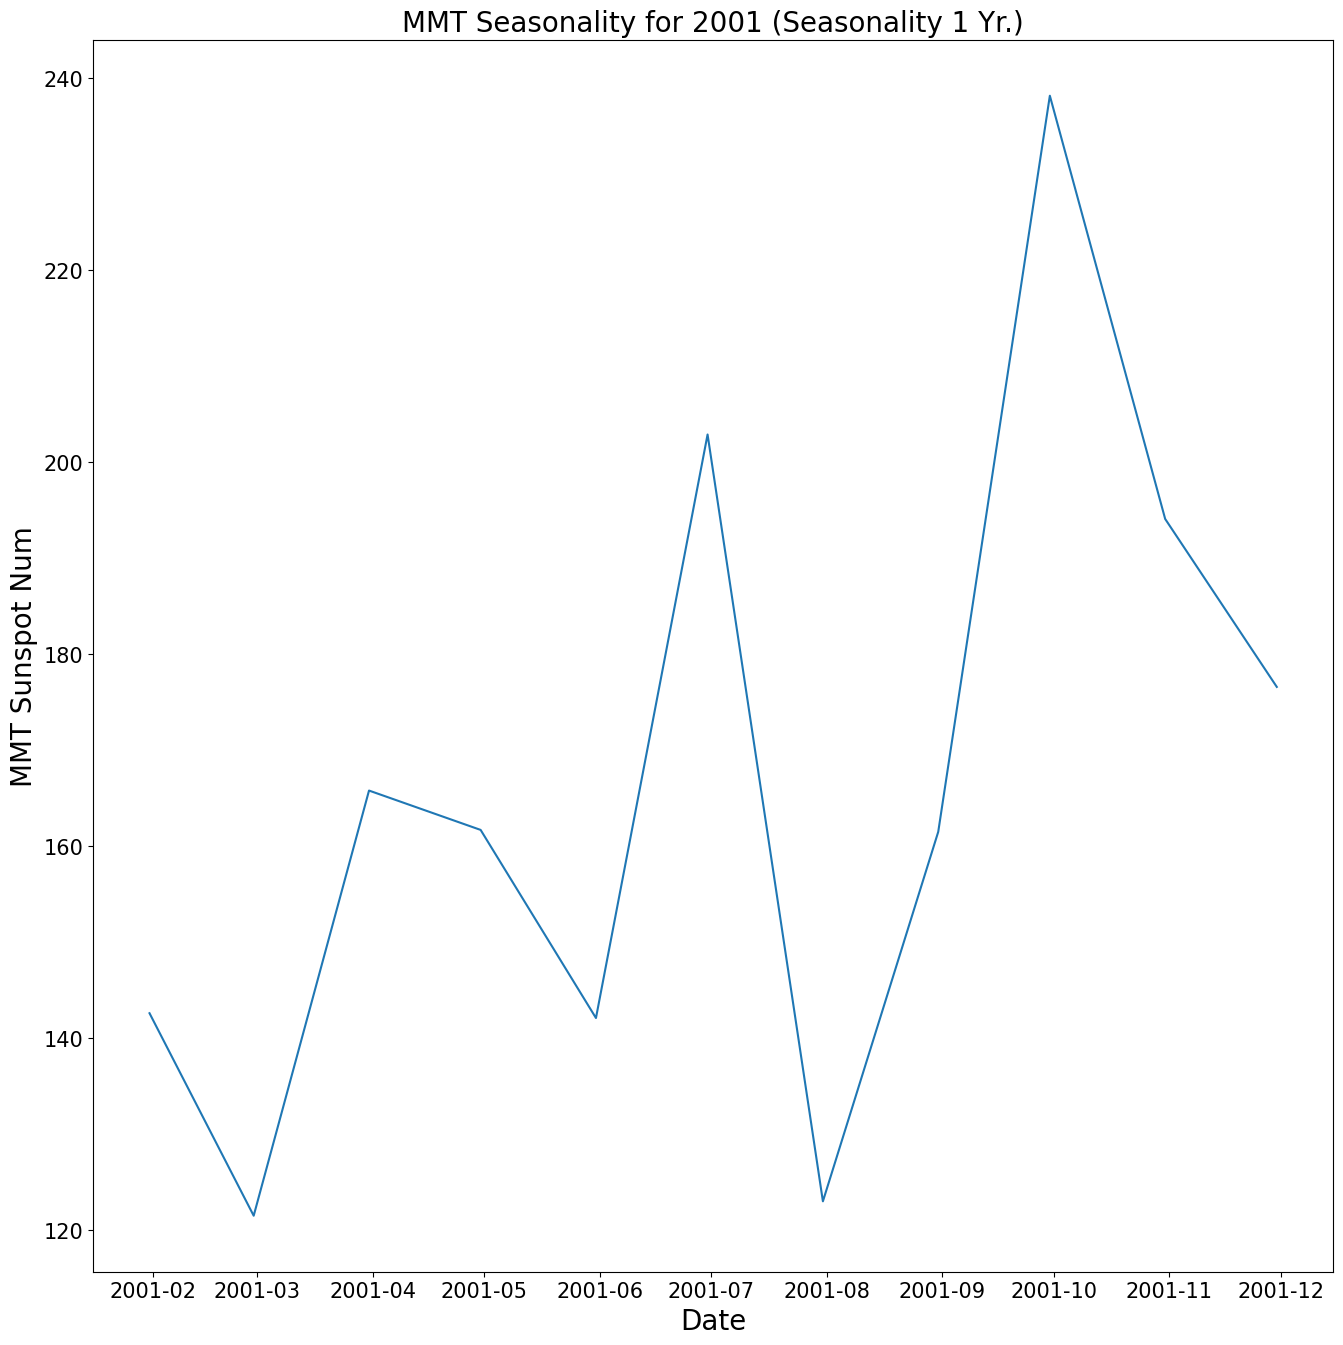

In [19]:
plot_sunspot_num(yearly_df, 0, yearly_df.shape[0]-1, "Seasonality 1 Yr.",
                 'MMT Seasonality for 2001', 'MMT Sunspot Num')

# Normalization Process

In [20]:
def get_scaler(scaler):
    scalers = {
        "minmax": MinMaxScaler,
        "standard": StandardScaler,
        "maxabs": MaxAbsScaler,
        "robust": RobustScaler,
    }
    return scalers.get(scaler.lower())()

def normalize_data(df):
    scaler_type = 'minmax'
    #scaler_type = input("Enter a scaler type (minmax,standard, maxabs, robust): ")
    if (scaler_type != 'minmax') and (scaler_type != 'standard') and (scaler_type != 'maxabs') and (scaler_type != 'robust'):
      runtime.unassign()

    scaler = get_scaler(scaler_type)
    normalized_data_MMT = scaler.fit_transform(df['Monthly Mean Total Sunspot Number'].
                                               values.reshape(-1,1))
    df['MMTSN_Norm'] = normalized_data_MMT
    return df, scaler

df_norm, scaler = normalize_data(df_entire)
df_norm_yr, scaler = normalize_data(yearly_df)

In [21]:
df_norm = df_norm.drop(columns = ['Monthly Mean Total Sunspot Number'])
df_norm

,MMTSN_Norm
Date,
1749-01-31,0.242843
1749-02-28,0.261929
1749-03-31,0.293069
1749-04-30,0.233049
1749-05-31,0.355851
...,...
2020-09-30,0.001507
2020-10-31,0.036163
2020-11-30,0.085384


In [22]:
df_norm_yr = df_norm_yr.drop(columns = ['Monthly Mean Total Sunspot Number'])
df_norm_yr

,MMTSN_Norm
Date,
2001-01-31,0.180805
2001-02-28,0.000000
2001-03-31,0.379606
2001-04-30,0.344473
2001-05-31,0.176521
2001-06-30,0.697515
2001-07-31,0.012853
2001-08-31,0.342759
2001-09-30,1.000000


## Plot VMT, VHT, Q Normalized based on Trend and Seasonality.

Now after normalization we can observe that the data range on y-axis is 0.0 - 1.0.

### Trend Plot

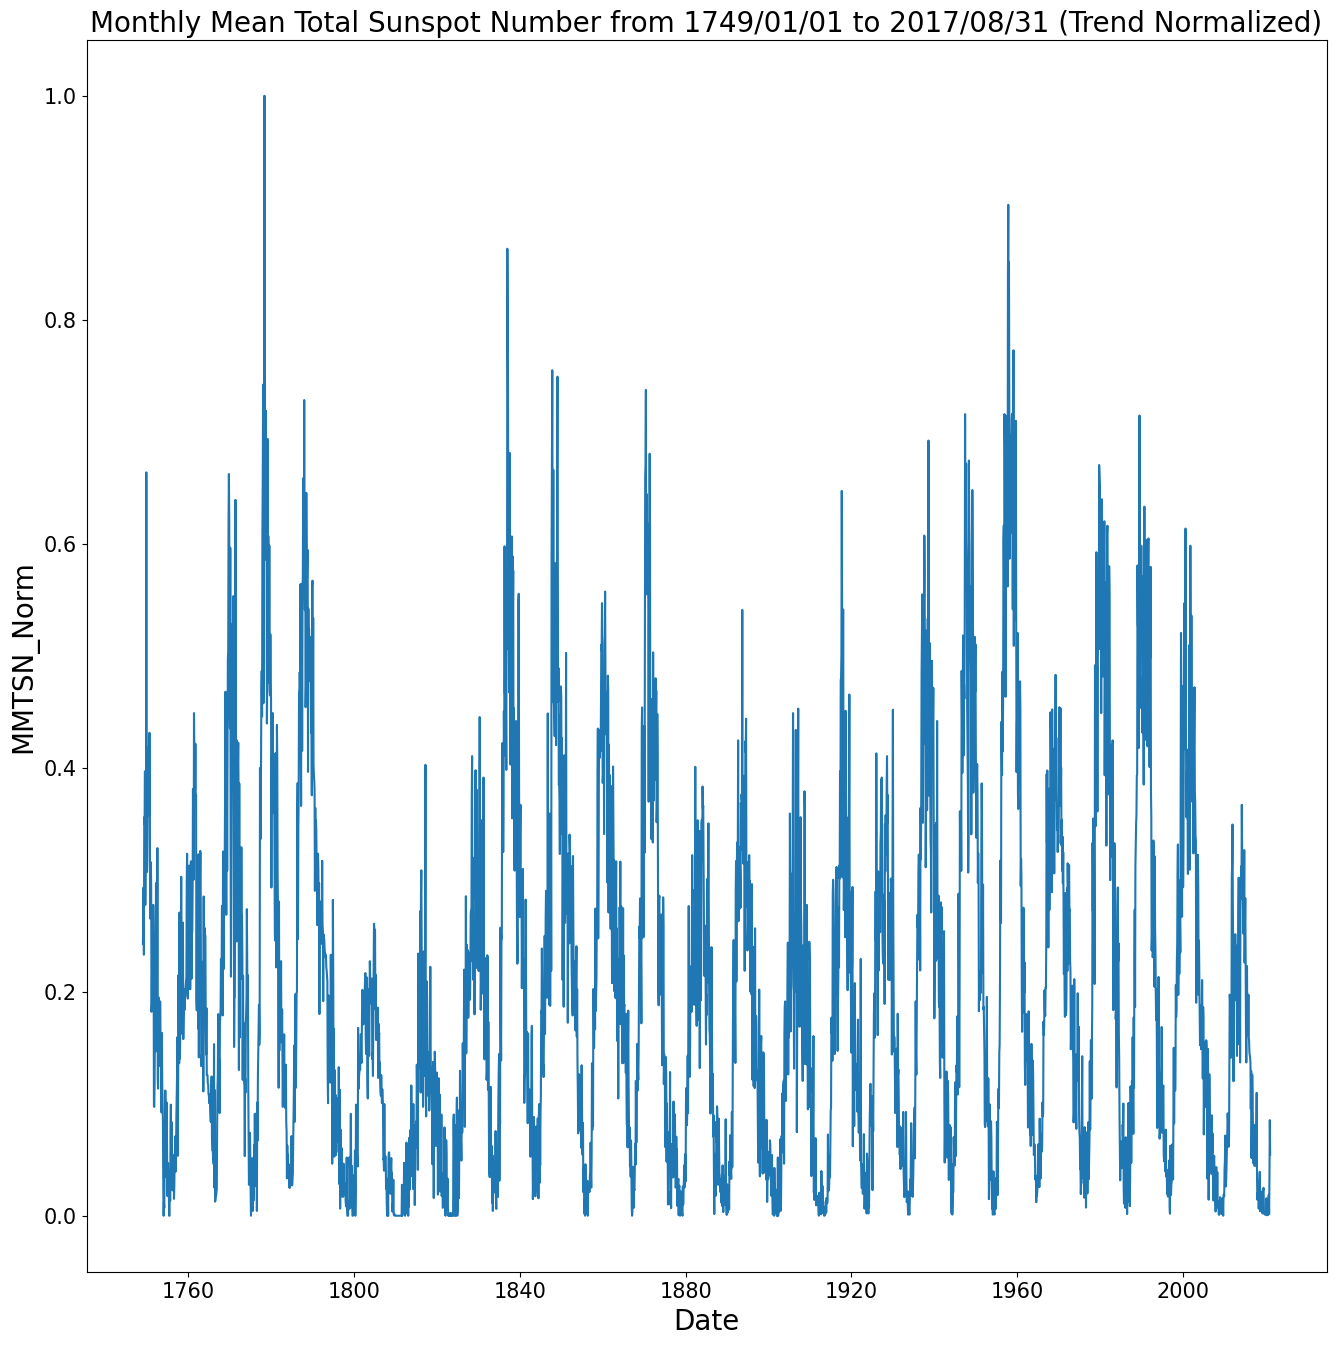

In [23]:
plot_sunspot_num(df_norm, 0, df_entire.shape[0]-1, "Trend Normalized", title_name,
                 'MMTSN_Norm')

### Daily Plots (Seasonality)

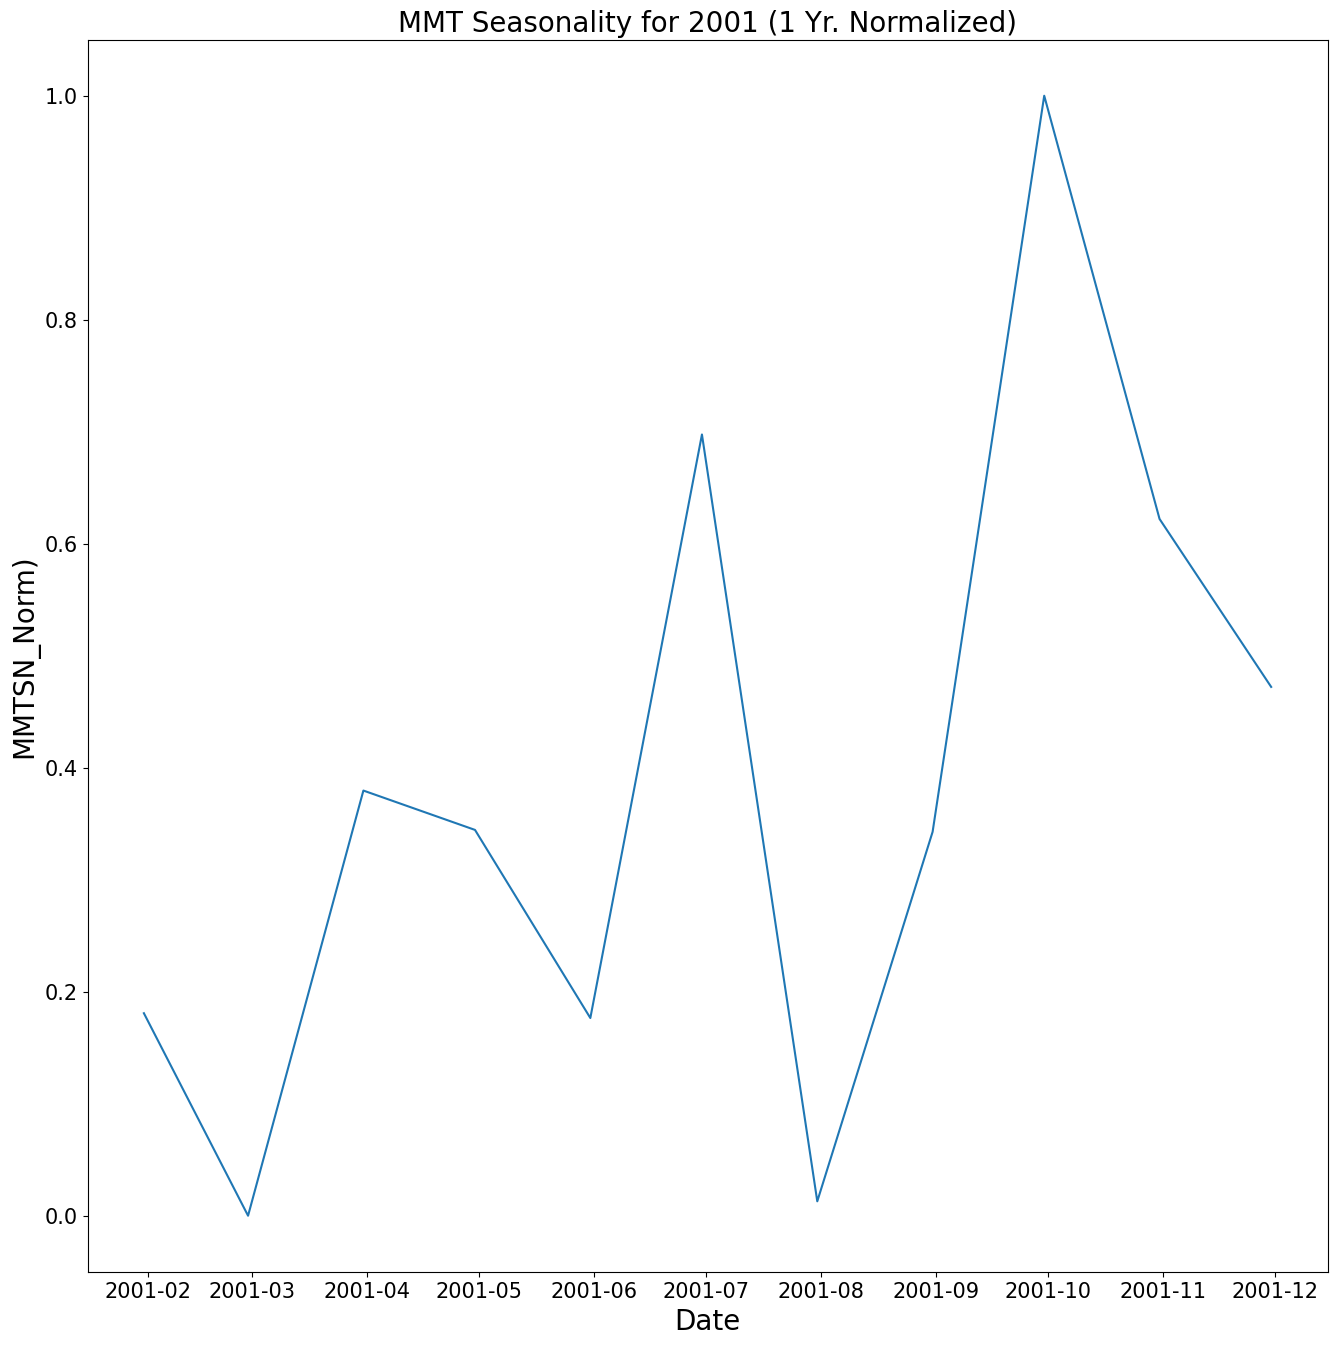

In [24]:
plot_sunspot_num(df_norm_yr, 0, df_norm_yr.shape[0]-1, "1 Yr. Normalized",
                  'MMT Seasonality for 2001', 'MMTSN_Norm)')

# Let's observe train and test data on the graph

## Split into Train/Test Data.

In [25]:
test_size = 0.2 # Set Split rate to 3:1 (80 % Training 20 % Test).
split_pos = int(df_entire.shape[0]*(1 - test_size))
df_entire = df_entire.reset_index()
df_entire

,Date,Monthly Mean Total Sunspot Number,MMTSN_Norm
0,1749-01-31,96.7,0.242843
1,1749-02-28,104.3,0.261929
2,1749-03-31,116.7,0.293069
3,1749-04-30,92.8,0.233049
4,1749-05-31,141.7,0.355851
...,...,...,...
3260,2020-09-30,0.6,0.001507
3261,2020-10-31,14.4,0.036163
3262,2020-11-30,34.0,0.085384
3263,2020-12-31,21.8,0.054746


In [26]:
# 2019-02-06 will be the date seperation. Dates past this will be the test set.
split_date = str(df_entire.Date[split_pos])
#split_date = split_date[:10]
#DOM_train = df_norm.loc[df_norm.index <= split_date].copy()
DOM_train = df_entire.loc[df_norm.index <= split_date].copy()
#DOM_test = df_norm.loc[df_norm.index > split_date].copy()
DOM_test = df_entire.loc[df_norm.index > split_date].copy()
split_date

'1966-09-30 00:00:00'

## Plot Train/Test Split Graphs.

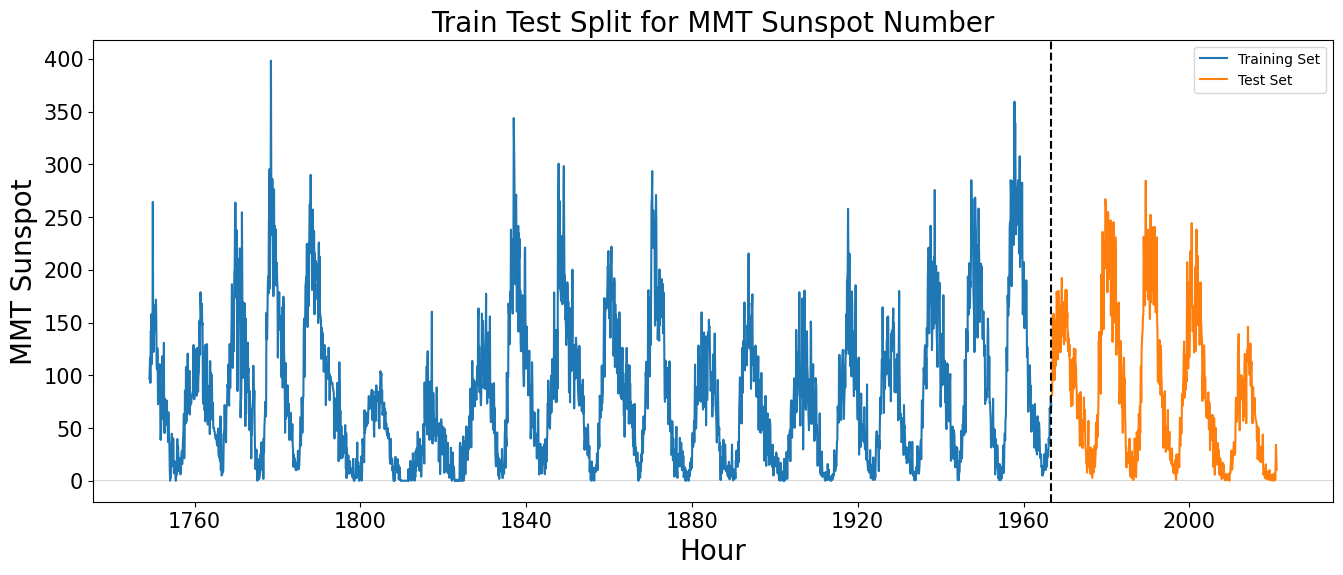

In [27]:
# Monthly Mean Total Sunspot Number Train Test Split
plt.figure(figsize=(16,6))
plt.plot(DOM_train['Date'], DOM_train['Monthly Mean Total Sunspot Number'],
         label='Training Set (Vehicle Miles)')
plt.plot(DOM_test['Date'], DOM_test['Monthly Mean Total Sunspot Number'],
         label='Testing Set (Vehicle Miles)')
plt.axvline(x = df_entire.Date[split_pos], color='black', ls='--')
plt.legend(['Training Set', 'Test Set'])
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.xlabel("Hour", fontsize = 20)
plt.ylabel("MMT Sunspot", fontsize = 20)
plt.title("Train Test Split for MMT Sunspot Number", fontsize = 20)
plt.show()

In [28]:
# We index the Datetime column after transformation
df_entire.set_index('Date', inplace=True)
df_entire.head()

,Monthly Mean Total Sunspot Number,MMTSN_Norm
Date,,
1749-01-31,96.7,0.242843
1749-02-28,104.3,0.261929
1749-03-31,116.7,0.293069
1749-04-30,92.8,0.233049
1749-05-31,141.7,0.355851


In [29]:
df_entire1 = df_entire.drop(columns = ['MMTSN_Norm'])
df_entire1

,Monthly Mean Total Sunspot Number
Date,
1749-01-31,96.7
1749-02-28,104.3
1749-03-31,116.7
1749-04-30,92.8
1749-05-31,141.7
...,...
2020-09-30,0.6
2020-10-31,14.4
2020-11-30,34.0


In [30]:
df_entire2 = df_entire.drop(columns = ['Monthly Mean Total Sunspot Number'])
df_entire2

,MMTSN_Norm
Date,
1749-01-31,0.242843
1749-02-28,0.261929
1749-03-31,0.293069
1749-04-30,0.233049
1749-05-31,0.355851
...,...
2020-09-30,0.001507
2020-10-31,0.036163
2020-11-30,0.085384


# Prepare Data for Training the Models.

* With the following function block, let's set our data set as training and test data set in a model appropriate way

In [31]:
def load_data(data, seq_len):
    X_train = []
    y_train = []

    for i in range(seq_len, len(data)):
        X_train.append(data.iloc[i-seq_len : i, 0])
        y_train.append(data.iloc[i, 0])

    # last days are going to be used in test
    X_test = X_train[split_pos:]
    y_test = y_train[split_pos:]

    # first  days are going to be used in training
    X_train = X_train[:split_pos]
    y_train = y_train[:split_pos]

    # convert to numpy array
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    # reshape data to input into RNN, LSTM, and GRU models
    X_train = np.reshape(X_train, (split_pos, seq_len, 1))
    X_test = np.reshape(X_test, (X_test.shape[0], seq_len, 1))

    return [X_train, y_train, X_test, y_test]

* **seq_len** parameter determines how far back the model will look at historical data, helping the model to capture time dependencies in a memory-aware way. If it gets too large, the model can become complex and prone to overlearning.

In [32]:
feature = 'Monthly Mean Total Sunspot Number'
#selected_df = df_entire1
selected_df = df_entire2
feature_norm = 'MMT Sunspot (Norm)'
feature_field = 'MMT Sunspot'

In [33]:
seq_len = 20
#seq_len = 6*24*30

# Let's create train, test data
#X_train, y_train, X_test, y_test = load_data(df_vht, seq_len)
#X_train, y_train, X_test, y_test = load_data(df_vmt, seq_len)
X_train, y_train, X_test, y_test = load_data(selected_df, seq_len)
#X_train, y_train, X_test, y_test = load_data(df_norm2, seq_len)


print('X_train.shape = ',X_train.shape)
print('y_train.shape = ', y_train.shape)
print('X_test.shape = ', X_test.shape)
print('y_test.shape = ',y_test.shape)

X_train.shape =  (2612, 20, 1)
y_train.shape =  (2612,)
X_test.shape =  (633, 20, 1)
y_test.shape =  (633,)


In [34]:
X_train

array([[[0.24284279],
        [0.26192868],
        [0.29306881],
        ...,
        [0.41863385],
        [0.35735811],
        [0.43119036]],

       [[0.26192868],
        [0.29306881],
        [0.23304872],
        ...,
        [0.35735811],
        [0.43119036],
        [0.38171773]],

       [[0.29306881],
        [0.23304872],
        [0.35585133],
        ...,
        [0.43119036],
        [0.38171773],
        [0.27498744]],

       ...,

       [[0.17001507],
        [0.20140633],
        [0.18232044],
        ...,
        [0.33550979],
        [0.44952285],
        [0.4331994 ]],

       [[0.20140633],
        [0.18232044],
        [0.17855349],
        ...,
        [0.44952285],
        [0.4331994 ],
        [0.39804119]],

       [[0.18232044],
        [0.17855349],
        [0.20391763],
        ...,
        [0.4331994 ],
        [0.39804119],
        [0.32772476]]])

In [35]:
X_test

array([[[0.17855349],
        [0.20391763],
        [0.20341537],
        ...,
        [0.39804119],
        [0.32772476],
        [0.2887996 ]],

       [[0.20391763],
        [0.20341537],
        [0.25062783],
        ...,
        [0.32772476],
        [0.2887996 ],
        [0.45203415]],

       [[0.20341537],
        [0.25062783],
        [0.39427423],
        ...,
        [0.2887996 ],
        [0.45203415],
        [0.39226519]],

       ...,

       [[0.02360623],
        [0.02285284],
        [0.02486188],
        ...,
        [0.01883476],
        [0.00150678],
        [0.03616273]],

       [[0.02285284],
        [0.02486188],
        [0.00301356],
        ...,
        [0.00150678],
        [0.03616273],
        [0.08538423]],

       [[0.02486188],
        [0.00301356],
        [0.00226017],
        ...,
        [0.03616273],
        [0.08538423],
        [0.05474636]]])

In [36]:
y_train

array([0.38171773, 0.27498744, 0.26494224, ..., 0.39804119, 0.32772476,
       0.2887996 ])

In [37]:
y_test

array([4.52034154e-01, 3.92265193e-01, 3.42039176e-01, 3.88749372e-01,
       4.16875942e-01, 3.82973380e-01, 3.05625314e-01, 3.90507283e-01,
       3.71170266e-01, 4.28176796e-01, 4.82923154e-01, 3.79457559e-01,
       4.26670015e-01, 3.76946258e-01, 3.44299347e-01, 3.48568559e-01,
       3.24711200e-01, 3.40030136e-01, 3.32496233e-01, 3.48066298e-01,
       3.96534405e-01, 4.54043194e-01, 3.65896534e-01, 3.89502762e-01,
       4.53289804e-01, 3.79959819e-01, 4.00050226e-01, 3.30738322e-01,
       3.53591160e-01, 3.07885485e-01, 3.38523355e-01, 2.96835761e-01,
       3.24460070e-01, 2.80763435e-01, 2.15720743e-01, 2.55148167e-01,
       2.04671020e-01, 1.77548970e-01, 2.88046208e-01, 2.18483174e-01,
       1.79055751e-01, 1.84329483e-01, 2.24761426e-01, 2.92566549e-01,
       2.18483174e-01, 3.14665997e-01, 2.85032647e-01, 2.25012557e-01,
       2.86037167e-01, 3.13159216e-01, 2.71973882e-01, 2.73480663e-01,
       2.27774987e-01, 2.18232044e-01, 1.48669011e-01, 1.61476645e-01,
      

## Essential Variables.

In [38]:
epochs = 10
batch_size = 1000
#loss = 'MAE'
loss = 'MSE'
#activation = 'sigmoid'
activation = 'tanh'
#activation = 'relu'

## Training Loss vs. Epochs Plot

Plotting Accuracy and Validation Accuracy vs Epochs. Code taken from https://machinelearningmastery.com/display-deep-learning-model-training-history-in-keras/.

In [39]:
def plot_training_loss(model, model_name):
    model.history.keys()
    plt.plot(model.history['loss'])
    plt.title('Training Loss vs. Epochs for {0}'.format(model_name))
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.show()

## Measure Time vs. Energy

In [40]:
def measure_time_and_energy(model, X_test):
    # Define general power estimates (in Watts).
    general_cpu_power_watts = 80 # General CPU power under load
    general_gpu_power_watts = 65 # General GPU power under load
    num_samples = X_test.shape[0]
    print("Measuring inference time and estimating energy on CPU...")
    # Create a separate model instance on CPU for measurement
    with tf.device('/CPU:0'):
        cpu_model = tf.keras.models.clone_model(model)
        # Build the cloned model with a dummy input to set input_shape attributes
        # Ensure the cpu_model is built to populate input_shape attributes on its
        # layers
        if not cpu_model.built:
            sample_input_shape = X_test.shape[1:] # e.g., (seq_len, 1)
            cpu_model.build((None,) + sample_input_shape)
        # Copy weights to the CPU model
        for cpu_layer, gpu_layer in zip(cpu_model.layers, model.layers):
            cpu_layer.set_weights(gpu_layer.get_weights())
        # Check CPU Model Inference Time.
        start_time_cpu = time.time()
        predictions_cpu = cpu_model.predict(X_test)
        end_time_cpu = time.time()
        cpu_inference_time = end_time_cpu - start_time_cpu
        print(f"Model CPU inference time: {cpu_inference_time:.4f} seconds")

        # Estimate energy consumption (Joules = Watts * Seconds)
        estimated_cpu_energy = general_cpu_power_watts * cpu_inference_time
        print(f"Estimated CPU energy consumption (using general power value): "
              f"{estimated_cpu_energy:.4f} J")
        # Convert to microjoules
        estimated_cpu_energy_uJ = estimated_cpu_energy * 1e6
        total_params = model.count_params()
        memory_energy_pJ = total_params * 100  # 100 pJ per access
        memory_energy_uJ = memory_energy_pJ / 1e6
        total_cpu_energy_uJ = estimated_cpu_energy_uJ + memory_energy_uJ
        print(f"Total CPU Energy: {total_cpu_energy_uJ} µJ")

    # Measure inference time and estimate energy on GPU if available.
    if tf.config.list_physical_devices('GPU'):
        print("\nMeasuring inference time and estimating energy on GPU...")
        with tf.device('/GPU:0'):
            # For GPU measurement, it's often good practice to run a small
            # warm-up pass to ensure everything is loaded and ready on the GPU.
            _ = model.predict(X_test[:10]) # Warm-up
            # Check Model GPU Inference Time.
            start_time_gpu = time.time()
            predictions_gpu = model.predict(X_test)
            end_time_gpu = time.time()
            gpu_inference_time = end_time_gpu - start_time_gpu
            print(f"Estimated GPU inference time: {gpu_inference_time:.4f} seconds")
            # Estimate energy consumption (Joules = Watts * Seconds)
            estimated_gpu_energy = general_gpu_power_watts * gpu_inference_time
            print(f"Estimated GPU energy consumption (using general power value): "
                  f"{estimated_gpu_energy:.4f} J")
            # Find Energy per sample by dividing GPU energy by number of samples.
            energy_per_sample_gpu = estimated_gpu_energy / num_samples
            print(f"energy_per_sample: {energy_per_sample_gpu * 1e6} µJ")
            # Convert to microjoules
            estimated_gpu_energy_uJ = estimated_gpu_energy * 1e6
            total_params = model.count_params()
            memory_energy_pJ = total_params * 100  # 100 pJ per access
            memory_energy_uJ = memory_energy_pJ / 1e6 # Convert back to uJ
            total_gpu_energy_uJ = estimated_gpu_energy_uJ + memory_energy_uJ
            # Calculated Total GPU Energy.
            print(f"Total GPU Energy: {total_gpu_energy_uJ} µJ")

    else:
        print("\nNo GPU available in this runtime. Cannot measure GPU "
              "inference time or estimate energy.")

# LSTM model

## Create LSTM Model.

In [41]:
lstm_model = Sequential()

lstm_model.add(LSTM(8, activation=activation, return_sequences=False,
                   input_shape=(40,1)))

lstm_model.add(Dense(1))
lstm_model.add(Dropout(0.2)) # Added Dropout layer to prevent overfitting

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

## Training LSTM Model.

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0829
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0728
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0638
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0557
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0484
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0425
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0380
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0338
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0301
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0287


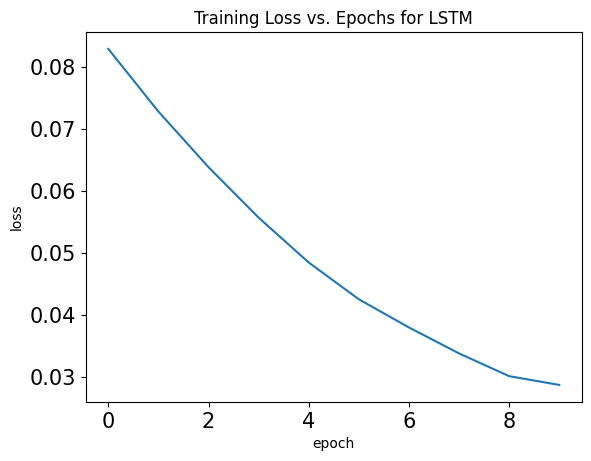

In [42]:
#lstm_model.compile(optimizer="adam",loss=loss)
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=loss)
lstm_model_epochs = lstm_model.fit(X_train, y_train, epochs=epochs,
                           batch_size=batch_size)
plot_training_loss(lstm_model_epochs, "LSTM")

## Evaluate LSTM Model using MAE, RMSE, and R2.

In [43]:
print("LSTM Predictions for Training Set")
lstm_predictions_train = lstm_model.predict(X_train)
print("RNN Predictions for Testing Set")
lstm_predictions_test = lstm_model.predict(X_test)
lstm_mae = mean_absolute_error(y_test,lstm_predictions_test)
print("MAE of RNN model = ",lstm_mae)
lstm_rmse =  mean_squared_error(y_test, lstm_predictions_test) ** 0.5
print("RMSE of RNN model = ", lstm_rmse)
#rnn_r2_score = r2_score(y_test,rnn_predictions_test)
#print("R2 Score of RNN model = ",rnn_r2_score)
lstm_mape_score = 100*mean_absolute_percentage_error(y_test,
                                                    lstm_predictions_test)
print("MAPE Score of RNN model = {0} %".format(lstm_mape_score))

LSTM Predictions for Training Set
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
RNN Predictions for Testing Set
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
MAE of RNN model =  0.11428695326010148
RMSE of RNN model =  0.14858955999516976
MAPE Score of RNN model = 77222551466970.95 %


## Reverse Transform Scaler to Convert to Real Values.

In [44]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
lstm_predictions_inv_train = scaler.inverse_transform(lstm_predictions_train)

y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
lstm_predictions_inv_test = scaler.inverse_transform(lstm_predictions_test)

# Get values after inverse transformation
y_train_inverse = y_train_inverse.flatten()
lstm_predictions_inv_train = lstm_predictions_inv_train.flatten()

y_test_inverse = y_test_inverse.flatten()
lstm_predictions_inv_test = lstm_predictions_inv_test.flatten()

## Show Actual and Predicted y values as Dataframes.

### With Training Dates.

In [45]:
first_6169_index_dates = df_entire.index[:X_train.shape[0]]
results_LSTM_train = pd.DataFrame({"Date": first_6169_index_dates,
                                  'Actual': y_train_inverse,
                                  'Predicted': lstm_predictions_inv_train})
results_LSTM_train

,Date,Actual,Predicted
0,1749-01-31,166.046459,144.686066
1,1749-02-28,153.591035,144.749481
2,1749-03-31,152.418759,144.349686
3,1749-04-30,158.338749,143.955399
4,1749-05-31,155.701130,143.810135
...,...,...,...
2607,1966-04-30,173.959317,142.103775
2608,1966-05-31,172.054370,142.767120
2609,1966-06-30,167.951406,143.300446
2610,1966-07-31,159.745480,143.655045


### With Testing Dates.

In [46]:
last_6169_index_dates = df_entire.index[-X_test.shape[0]:]
results_LSTM_test = pd.DataFrame({"Date":last_6169_index_dates,
                                 'Actual': y_test_inverse,
                                 'Predicted': lstm_predictions_inv_test})
results_LSTM_test

,Date,Actual,Predicted
0,1968-05-31,174.252386,143.505630
1,1968-06-30,167.277348,144.041504
2,1968-07-31,161.415972,144.214050
3,1968-08-31,166.867052,144.187622
4,1968-09-30,170.149422,144.359558
...,...,...,...
628,2020-09-30,121.675841,134.196198
629,2020-10-31,125.720191,134.171753
630,2020-11-30,131.464340,134.255295
631,2020-12-31,127.888900,134.467361


## Plotting Predictions for Monthly Mean Sunspot Number made by LSTM Model.

### Only Testing Data.

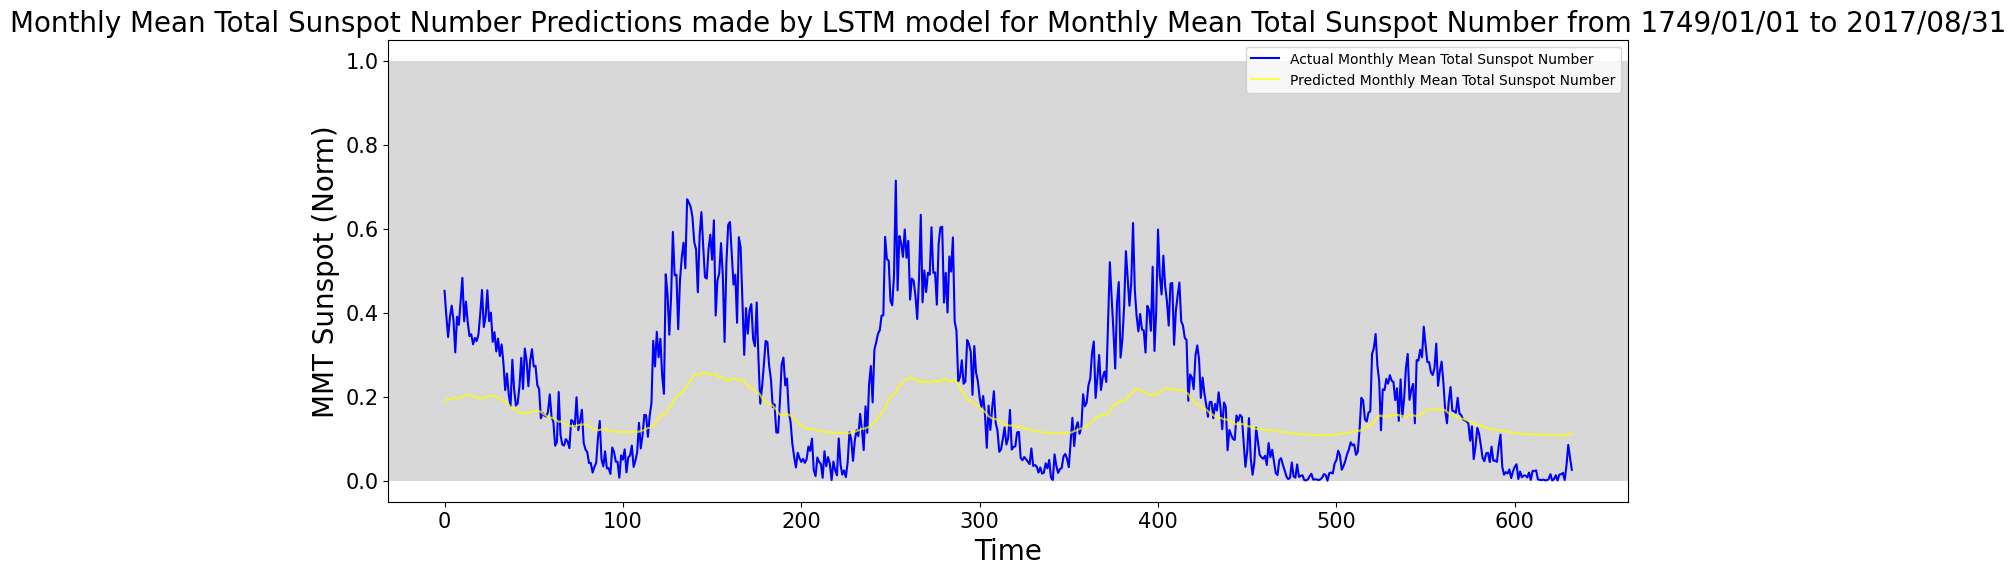

In [47]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(lstm_predictions_test, alpha=0.7, color='yellow',
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions made by LSTM model for {1}".
          format(feature, title_name), fontsize = 20)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

### Training and Testing Data combined.

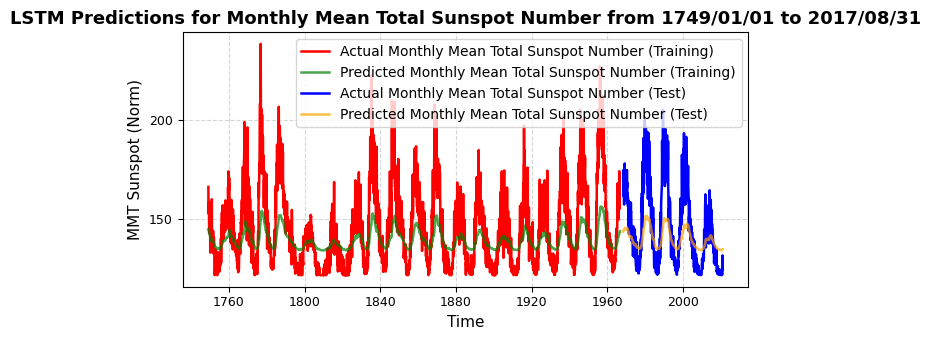

In [48]:
# 🔹 Create figure sized for IEEE 2-column layout
plt.figure(figsize=(6.5, 3.5))  # 6.5in width fits one column in IEEE

# 🔹 Plot training data
plt.plot(results_LSTM_train['Date'], results_LSTM_train['Actual'], color='red',
         label=f'Actual {feature} (Training)', linewidth=1.8)
plt.plot(results_LSTM_train['Date'], results_LSTM_train['Predicted'], color='green',
         label=f'Predicted {feature} (Training)', alpha=0.7, linewidth=1.8)

# 🔹 Plot test data
plt.plot(results_LSTM_test['Date'], results_LSTM_test['Actual'], color='blue',
         label=f'Actual {feature} (Test)', linewidth=1.8)
plt.plot(results_LSTM_test['Date'], results_LSTM_test['Predicted'], color='orange',
         label=f'Predicted {feature} (Test)', alpha=0.7, linewidth=1.8)

# 🔹 Formatting
plt.title(f'LSTM Predictions for {title_name}', fontsize=13, fontweight='bold')
plt.xlabel('Time', fontsize=11)
plt.ylabel(feature_norm, fontsize=11)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 🔹 Export for Appendix
plt.show()

## Combine Actual and Predicted Results for Train and Test Cases for LSTM.

In [49]:
results_LSTM = [results_LSTM_train, results_LSTM_test]
results_LSTM = pd.concat(results_LSTM)
display(results_LSTM)

,Date,Actual,Predicted
0,1749-01-31,166.046459,144.686066
1,1749-02-28,153.591035,144.749481
2,1749-03-31,152.418759,144.349686
3,1749-04-30,158.338749,143.955399
4,1749-05-31,155.701130,143.810135
...,...,...,...
628,2020-09-30,121.675841,134.196198
629,2020-10-31,125.720191,134.171753
630,2020-11-30,131.464340,134.255295
631,2020-12-31,127.888900,134.467361


## Plotting Residuals for Actual and Predicted Results for LSTM.

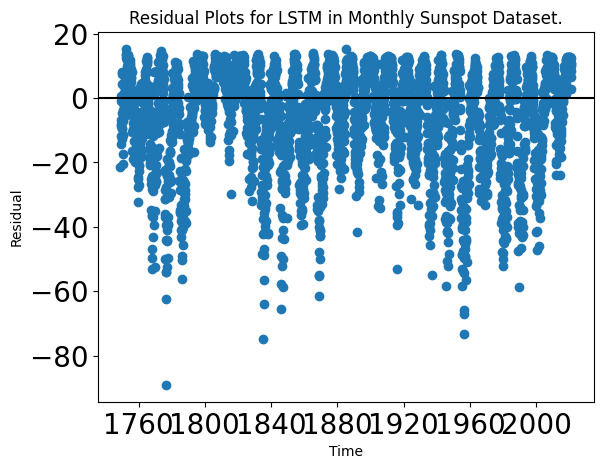

In [50]:
actual_arr_LSTM = np.array(results_LSTM['Actual'])
predicted_arr_LSTM = np.array(results_LSTM['Predicted'])
residuals_LSTM = predicted_arr_LSTM - actual_arr_LSTM
plt.scatter(results_LSTM['Date'], residuals_LSTM)
plt.axhline(y=0, color = 'black')
plt.title("Residual Plots for LSTM in Monthly Sunspot Dataset.")
#plt.locator_params(axis='x', nbins=10)
#plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

From the residual plots for the RNN model, it can be concluded that the RNN model is a good fit.

## Energy Consumption

In [51]:
# Find total energy consumption using GPU.
measure_time_and_energy(lstm_model, X_test)

Measuring inference time and estimating energy on CPU...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Model CPU inference time: 0.3323 seconds
Estimated CPU energy consumption (using general power value): 26.5842 J
Total CPU Energy: 26584205.660341408 µJ

No GPU available in this runtime. Cannot measure GPU inference time or estimate energy.


# GRU Model

## Create GRU Model.

In [52]:
gru_model = Sequential()

gru_model.add(GRU(8,activation=activation, return_sequences=False,
                  input_shape=(40,1)))
gru_model.add(Dropout(0.5))

gru_model.add(Dense(1))

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

## Train GRU Model.

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0385
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0322
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0281
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0240 
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0226
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0212
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0221
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0205
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0208
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0197


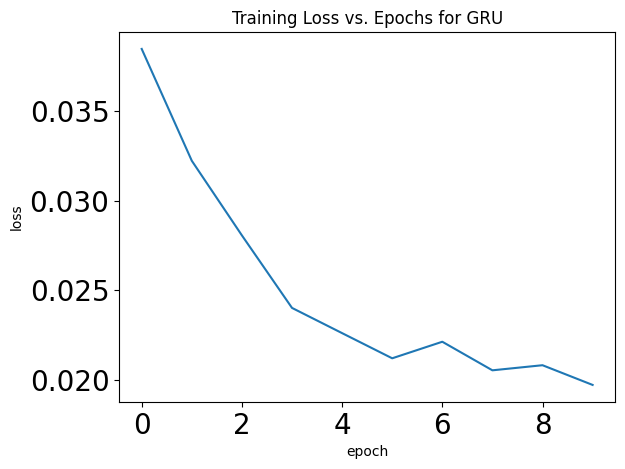

In [53]:
gru_model.compile(optimizer="adam",loss=loss)
gru_epochs = gru_model.fit(X_train, y_train, epochs=epochs,
                           batch_size=batch_size)
plot_training_loss(gru_epochs, "GRU")

## Evaluate GRU model using MAE, RMSE, and R^2.

In [54]:
print("GRU Predictions for Training Set")
gru_pred_train = gru_model.predict(X_train)
print("GRU Predictions for Testing Set")
gru_pred_test = gru_model.predict(X_test)
gru_mae = mean_absolute_error(y_test,gru_pred_test)
print("MAE of GRU model = ",gru_mae)
gru_rmse =  mean_squared_error(y_test,gru_pred_test) ** 0.5
print("RMSE of GRU model = ",gru_rmse)
#gru_r2_score = r2_score(y_test, gru_pred_test)
#print("R^2 Score of GRU model = ",gru_r2_score)
gru_mape_score = 100*mean_absolute_percentage_error(y_test, gru_pred_test)
print("MAPE Score of GRU model = {0} %".format(gru_mape_score))

GRU Predictions for Training Set
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
GRU Predictions for Testing Set
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
MAE of GRU model =  0.08036236083663098
RMSE of GRU model =  0.10060722310287358
MAPE Score of GRU model = 73197784812702.53 %


## Reverse transform scaler to convert to real values.

In [55]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
gru_pred_inv_train = scaler.inverse_transform(gru_pred_train)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
gru_pred_inv_test = scaler.inverse_transform(gru_pred_test)

# Get values after inverse transformation
y_train_inverse = y_train_inverse.flatten()
gru_pred_inv_train = gru_pred_inv_train.flatten()
y_test_inverse = y_test_inverse.flatten()
gru_pred_inv_test = gru_pred_inv_test.flatten()

## Showing Actual y and Predicted y values as Dataframes.

### With Training Dates.

In [56]:
results_GRU_train = pd.DataFrame({"Date":first_6169_index_dates,
                            'Actual': y_train_inverse,
                            'Predicted': gru_pred_inv_train})
results_GRU_train

,Date,Actual,Predicted
0,1749-01-31,166.046459,156.101166
1,1749-02-28,153.591035,155.405029
2,1749-03-31,152.418759,151.703339
3,1749-04-30,158.338749,149.675873
4,1749-05-31,155.701130,150.360214
...,...,...,...
2607,1966-04-30,173.959317,151.435242
2608,1966-05-31,172.054370,155.245651
2609,1966-06-30,167.951406,156.578461
2610,1966-07-31,159.745480,156.146515


### With Testing Dates.

In [57]:
results_GRU_test = pd.DataFrame({"Date":last_6169_index_dates,
                            'Actual': y_test_inverse,
                            'Predicted': gru_pred_inv_test})
results_GRU_test

,Date,Actual,Predicted
0,1968-05-31,174.252386,151.383392
1,1968-06-30,167.277348,155.273743
2,1968-07-31,161.415972,155.339722
3,1968-08-31,166.867052,153.816177
4,1968-09-30,170.149422,154.540192
...,...,...,...
628,2020-09-30,121.675841,133.717911
629,2020-10-31,125.720191,133.197968
630,2020-11-30,131.464340,134.174942
631,2020-12-31,127.888900,136.238892


## Plotting Predictions for AEP_MW made by GRU Model.

### Testing Data Only.

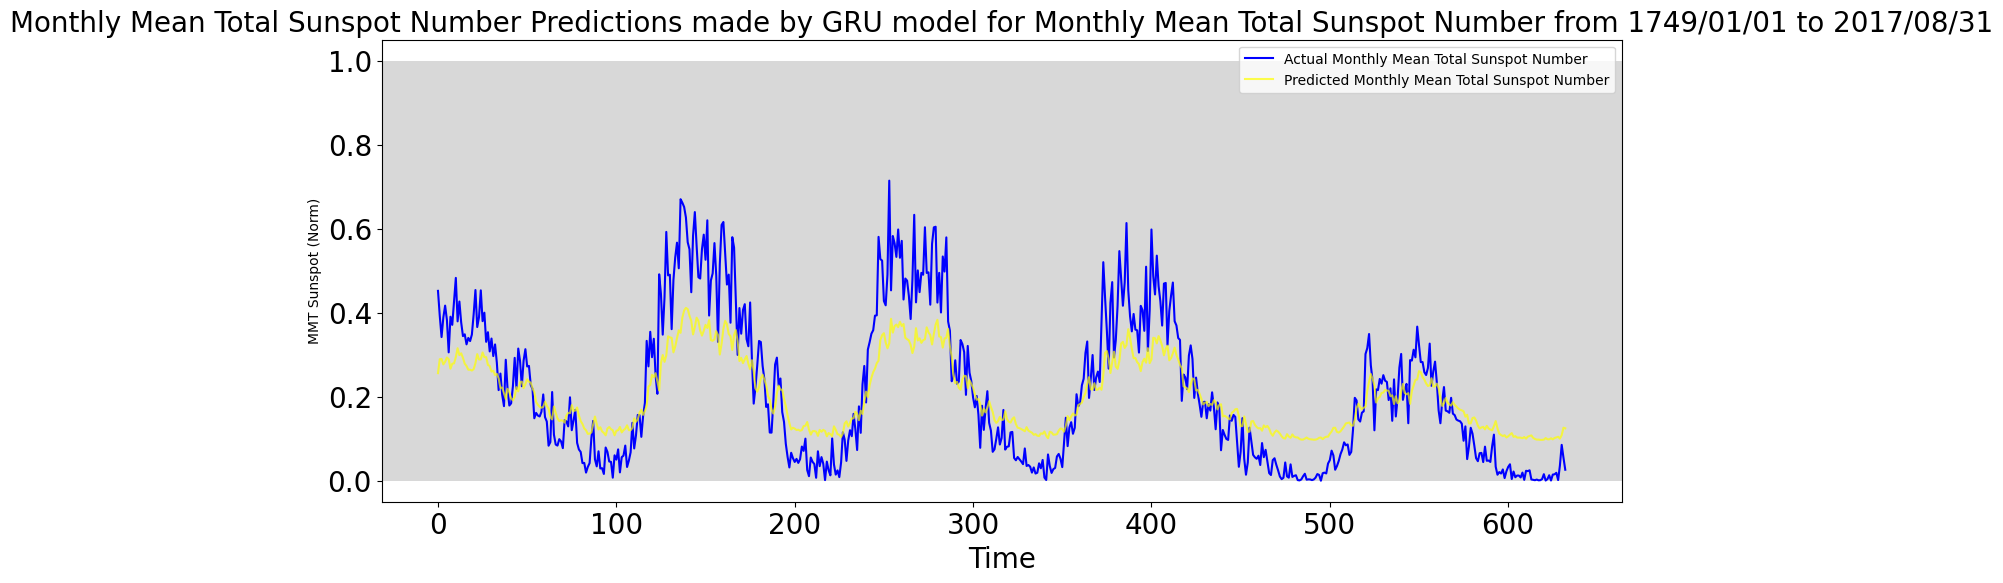

In [58]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(gru_pred_test, alpha=0.7, color='yellow',
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions made by GRU model for {1}".
          format(feature, title_name), fontsize = 20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 10)
plt.legend()
plt.show()

### Training and Test Data Combined.

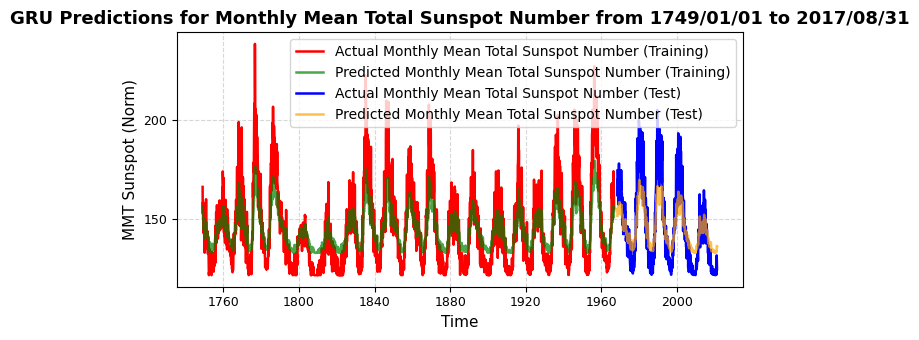

In [59]:
# 🔹 Create figure sized for IEEE 2-column layout
plt.figure(figsize=(6.5, 3.5))  # 6.5in width fits one column in IEEE

# 🔹 Plot training data
plt.plot(results_GRU_train['Date'], results_GRU_train['Actual'], color='red',
         label=f'Actual {feature} (Training)', linewidth=1.8)
plt.plot(results_GRU_train['Date'], results_GRU_train['Predicted'], color='green',
         label=f'Predicted {feature} (Training)', alpha=0.7, linewidth=1.8)

# 🔹 Plot test data
plt.plot(results_GRU_test['Date'], results_GRU_test['Actual'], color='blue',
         label=f'Actual {feature} (Test)', linewidth=1.8)
plt.plot(results_GRU_test['Date'], results_GRU_test['Predicted'], color='orange',
         label=f'Predicted {feature} (Test)', alpha=0.7, linewidth=1.8)

# 🔹 Formatting
plt.title(f'GRU Predictions for {title_name}', fontsize=13, fontweight='bold')
plt.xlabel('Time', fontsize=11)
plt.ylabel(feature_norm, fontsize=11)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 🔹 Export for Appendix
plt.show()

## Combine Actual and Predicted Results for Train and Test Cases for GRU.

In [60]:
results_GRU = [results_GRU_train, results_GRU_test]
results_GRU = pd.concat(results_GRU)
display(results_GRU)

,Date,Actual,Predicted
0,1749-01-31,166.046459,156.101166
1,1749-02-28,153.591035,155.405029
2,1749-03-31,152.418759,151.703339
3,1749-04-30,158.338749,149.675873
4,1749-05-31,155.701130,150.360214
...,...,...,...
628,2020-09-30,121.675841,133.717911
629,2020-10-31,125.720191,133.197968
630,2020-11-30,131.464340,134.174942
631,2020-12-31,127.888900,136.238892


## Plotting Residuals for Actual and Predicted Results for GRU.

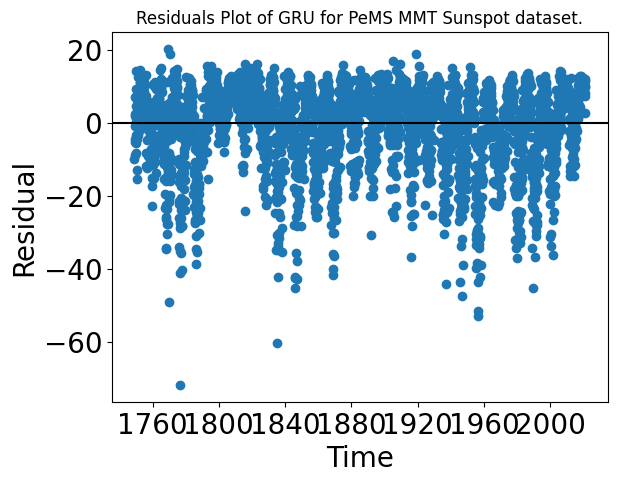

In [61]:
# Plotting Residuals for Actual and Predicted Results for GRU.
actual_arr_GRU = np.array(results_GRU['Actual'])
predicted_arr_GRU = np.array(results_GRU['Predicted'])
residuals_GRU = predicted_arr_GRU - actual_arr_GRU
plt.scatter(results_GRU['Date'], residuals_GRU)
plt.axhline(y=0, color = 'black')
plt.title("Residuals Plot of GRU for PeMS {} dataset.".format(feature_field))
#plt.locator_params(axis='x', nbins=10)
#plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel("Time", fontsize = 20)
plt.ylabel("Residual", fontsize = 20)
plt.show()

From the residual plots for the GRU model, it can be concluded that the GRU model is a good fit.

## Energy Consumption

In [62]:
# Find total energy consumption using GPU.
measure_time_and_energy(gru_model, X_test)

Measuring inference time and estimating energy on CPU...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Model CPU inference time: 0.4063 seconds
Estimated CPU energy consumption (using general power value): 32.5016 J
Total CPU Energy: 32501564.053178906 µJ

No GPU available in this runtime. Cannot measure GPU inference time or estimate energy.


# CNN (Conv1D) model

### Create CNN Model.

In [63]:
cnn_model = Sequential()

cnn_model.add(Conv1D(filters=8, kernel_size=3, activation=activation,
                     input_shape=(20,1)))
cnn_model.add(MaxPooling1D(pool_size=2))

cnn_model.add(Conv1D(filters=8, kernel_size=3, activation=activation,
                     input_shape=(20,1)))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Dropout(0.2)) # Added Dropout layer

cnn_model.add(Flatten())
cnn_model.add(Dense(16, activation=activation))
cnn_model.add(Dense(1))
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 8)          │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 7, 8)           │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

### Train CNN model.

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.2770
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1990
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1402
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0973
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0681
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0469
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0333
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0268
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0248
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0243


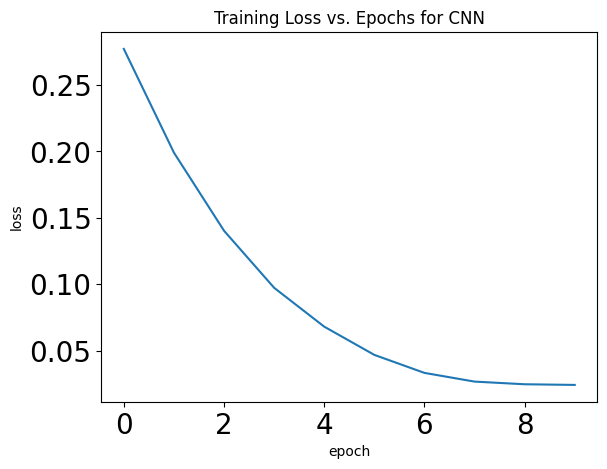

In [64]:
cnn_model.compile(optimizer="adam",loss=loss)
cnn_epochs = cnn_model.fit(X_train, y_train, epochs=epochs,
                           batch_size=batch_size)
plot_training_loss(cnn_epochs, "CNN")

### Evaluate CNN model using MAE, RMSE, and R^2.

In [65]:
print("CNN Predictions for Training Set")
cnn_pred_train = cnn_model.predict(X_train)
print("CNN Predictions for Testing Set")
cnn_pred_test = cnn_model.predict(X_test)
cnn_mae = mean_absolute_error(y_test,cnn_pred_test)
print("MAE of CNN model = ",cnn_mae)
cnn_rmse =  mean_squared_error(y_test,cnn_pred_test) ** 0.5
print("RMSE of CNN model = ",cnn_rmse)
#cnn_r2_score = r2_score(y_test, cnn_pred_test)
#print("R^2 Score of CNN model = ",cnn_r2_score)
cnn_mape_score = 100*mean_absolute_percentage_error(y_test, cnn_pred_test)
print("MAPE Score of CNN model = {0} %".format(cnn_mape_score))

CNN Predictions for Training Set
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
CNN Predictions for Testing Set
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
MAE of CNN model =  0.12588836978226273
RMSE of CNN model =  0.1438152266438151
MAPE Score of CNN model = 146992382641215.84 %


### Reverse transform scaler to convert to real values.

In [66]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
cnn_pred_inv_train = scaler.inverse_transform(cnn_pred_train)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
cnn_pred_inv_test = scaler.inverse_transform(cnn_pred_test)

# Get values after inverse transformation
y_train_inverse = y_train_inverse.flatten()
cnn_pred_inv_train = cnn_pred_inv_train.flatten()
y_test_inverse = y_test_inverse.flatten()
cnn_pred_inv_test = cnn_pred_inv_test.flatten()

### Showing Actual y and Predicted y values as Dataframes.

#### With Training Dates.

In [67]:
results_CNN_train = pd.DataFrame({"Date":first_6169_index_dates,
                                 'Actual': y_train_inverse,
                                 'Predicted': cnn_pred_inv_train})
results_CNN_train

,Date,Actual,Predicted
0,1749-01-31,166.046459,164.039383
1,1749-02-28,153.591035,159.583572
2,1749-03-31,152.418759,154.863281
3,1749-04-30,158.338749,154.807922
4,1749-05-31,155.701130,153.783508
...,...,...,...
2607,1966-04-30,173.959317,161.035690
2608,1966-05-31,172.054370,156.873764
2609,1966-06-30,167.951406,150.188126
2610,1966-07-31,159.745480,154.666779


#### With Testing Dates.

In [68]:
results_CNN_test = pd.DataFrame({"Date":last_6169_index_dates,
                                 'Actual': y_test_inverse,
                                 'Predicted': cnn_pred_inv_test})
results_CNN_test

,Date,Actual,Predicted
0,1968-05-31,174.252386,162.641037
1,1968-06-30,167.277348,165.944077
2,1968-07-31,161.415972,163.566208
3,1968-08-31,166.867052,160.882599
4,1968-09-30,170.149422,165.438995
...,...,...,...
628,2020-09-30,121.675841,145.406097
629,2020-10-31,125.720191,145.537155
630,2020-11-30,131.464340,145.635025
631,2020-12-31,127.888900,145.114105


### Plotting Predictions for AEP_MW made by CNN Model.

#### Only Testing Data.

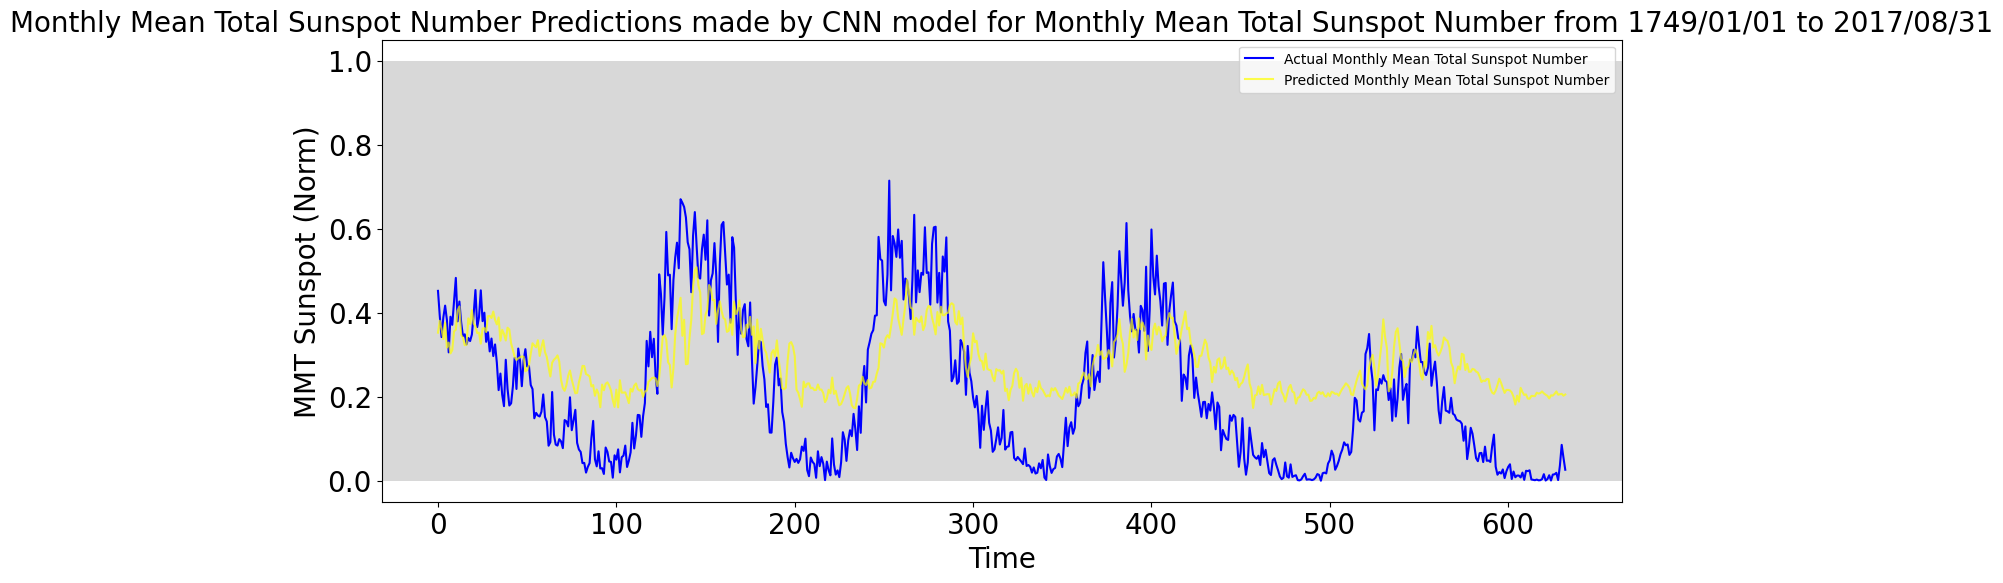

In [69]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(cnn_pred_test, alpha=0.7, color='yellow',
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions made by CNN model for {1}".
          format(feature, title_name), fontsize = 20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

#### Training and Test Data Combined.

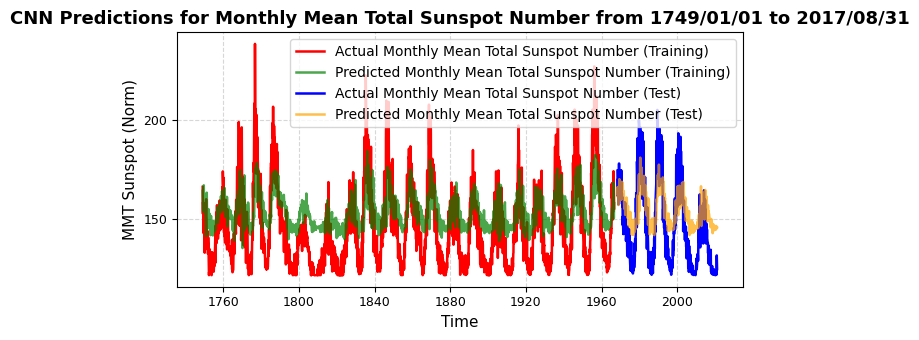

In [70]:
# 🔹 Create figure sized for IEEE 2-column layout
plt.figure(figsize=(6.5, 3.5))  # 6.5in width fits one column in IEEE

# 🔹 Plot training data
plt.plot(results_CNN_train['Date'], results_CNN_train['Actual'], color='red',
         label=f'Actual {feature} (Training)', linewidth=1.8)
plt.plot(results_CNN_train['Date'], results_CNN_train['Predicted'], color='green',
         label=f'Predicted {feature} (Training)', alpha=0.7, linewidth=1.8)

# 🔹 Plot test data
plt.plot(results_CNN_test['Date'], results_CNN_test['Actual'], color='blue',
         label=f'Actual {feature} (Test)', linewidth=1.8)
plt.plot(results_CNN_test['Date'], results_CNN_test['Predicted'], color='orange',
         label=f'Predicted {feature} (Test)', alpha=0.7, linewidth=1.8)

# 🔹 Formatting
plt.title(f'CNN Predictions for {title_name}', fontsize=13, fontweight='bold')
plt.xlabel('Time', fontsize=11)
plt.ylabel(feature_norm, fontsize=11)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 🔹 Export for Appendix
plt.show()

### Combine Actual and Predicted Results for Train and Test Cases for CNN.

In [71]:
results_CNN = [results_CNN_train, results_CNN_test]
results_CNN = pd.concat(results_CNN)
display(results_CNN)

,Date,Actual,Predicted
0,1749-01-31,166.046459,164.039383
1,1749-02-28,153.591035,159.583572
2,1749-03-31,152.418759,154.863281
3,1749-04-30,158.338749,154.807922
4,1749-05-31,155.701130,153.783508
...,...,...,...
628,2020-09-30,121.675841,145.406097
629,2020-10-31,125.720191,145.537155
630,2020-11-30,131.464340,145.635025
631,2020-12-31,127.888900,145.114105


### Plotting Residuals for Actual and Predicted Results for CNN.

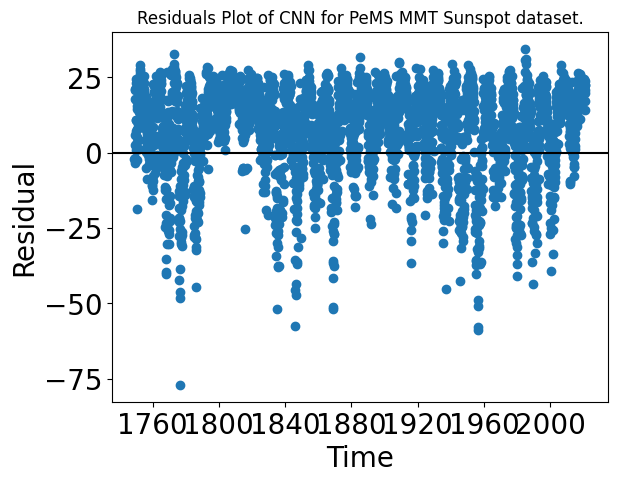

In [72]:
actual_arr_CNN = np.array(results_CNN['Actual'])
predicted_arr_CNN = np.array(results_CNN['Predicted'])
residuals_CNN = predicted_arr_CNN - actual_arr_CNN
plt.scatter(results_CNN['Date'], residuals_CNN)
plt.axhline(y=0, color = 'black')
plt.title("Residuals Plot of CNN for PeMS {} dataset.".format(feature_field))
#plt.locator_params(axis='x', nbins=10)
#plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel("Time", fontsize = 20)
plt.ylabel("Residual", fontsize = 20)
plt.show()

From the residual plots for the CNN model, it can be concluded that the CNN model is a good fit.

### Energy Consumption

In [73]:
# Find total energy consumption using GPU.
measure_time_and_energy(cnn_model, X_test)

Measuring inference time and estimating energy on CPU...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Model CPU inference time: 0.2410 seconds
Estimated CPU energy consumption (using general power value): 19.2820 J
Total CPU Energy: 19281997.745564062 µJ

No GPU available in this runtime. Cannot measure GPU inference time or estimate energy.


# CNN-LSTM (Hybrid DNN) Model

## Create CNN-LSTM Model

In [74]:
cnn_lstm_model = Sequential()

cnn_lstm_model.add(Conv1D(filters=8, kernel_size=3, activation=activation,
                          input_shape=(40,1)))
cnn_lstm_model.add(MaxPooling1D(pool_size=2))

cnn_lstm_model.add(LSTM(8,activation=activation,return_sequences=False))
cnn_lstm_model.add(Dropout(0.1))

cnn_lstm_model.add(Dense(1))
cnn_lstm_model.compile(optimizer='adam', loss='mse')
cnn_lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 38, 8)          │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 19, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585 (2.29 KB)

 Trainable params: 585 (2.29 KB)

 Non-trainable params: 0 (0.00 B)

## Train CNN-LSTM Model

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0146
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0121
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0112
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0127
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0117
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0111
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0101
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0105
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0104
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0099


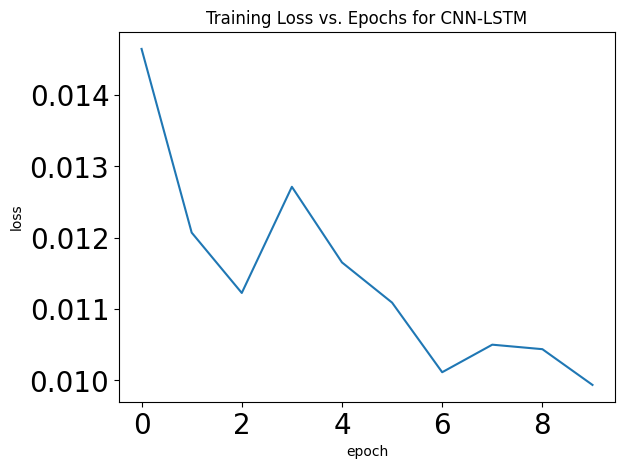

In [75]:
cnn_lstm_model.compile(optimizer="adam",loss=loss)
cnn_lstm_epochs = cnn_lstm_model.fit(X_train, y_train, epochs=epochs,
                                     batch_size=batch_size)
plot_training_loss(cnn_lstm_epochs, "CNN-LSTM")

## Evaluate CNN-LSTM Model using MAE, RMSE, and R2.

In [76]:
print("CNN-LSTM Predictions for Training Set")
cnn_lstm_pred_train = cnn_lstm_model.predict(X_train)
print("CNN-LSTM Predictions for Testing Set")
cnn_lstm_pred_test = cnn_lstm_model.predict(X_test)
cnn_lstm_mae = mean_absolute_error(y_test,cnn_lstm_pred_test)
print("MAE of CNN-LSTM model = ",cnn_lstm_mae)
cnn_lstm_rmse =  mean_squared_error(y_test,cnn_lstm_pred_test) ** 0.5
print("RMSE of CNN-LSTM model = ",cnn_lstm_rmse)
cnn_lstm_r2_score = r2_score(y_test, cnn_lstm_pred_test)
print("R^2 Score of CNN-LSTM model = ",cnn_lstm_r2_score)
cnn_lstm_mape_score = 100*mean_absolute_percentage_error(y_test,
                                                         cnn_lstm_pred_test)
print("MAPE Score of CNN-LSTM model = {0} %".format(cnn_lstm_mape_score))

CNN-LSTM Predictions for Training Set
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
CNN-LSTM Predictions for Testing Set
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
MAE of CNN-LSTM model =  0.06283560903568708
RMSE of CNN-LSTM model =  0.0848675472638863
R^2 Score of CNN-LSTM model =  0.7655677956907325
MAPE Score of CNN-LSTM model = 2864117261189.74 %


## Reverse Transform Scaler to Convert to Real Values.

In [77]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
cnn_lstm_pred_inv_train = scaler.inverse_transform(cnn_lstm_pred_train)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
cnn_lstm_pred_inv_test = scaler.inverse_transform(cnn_lstm_pred_test)

# Get values after inverse transformation.
y_train_inverse = y_train_inverse.flatten()
cnn_lstm_pred_inv_train = cnn_lstm_pred_inv_train.flatten()
y_test_inverse = y_test_inverse.flatten()
cnn_lstm_pred_inv_test = cnn_lstm_pred_inv_test.flatten()

## Showing Actual y and Predicted y values as Dataframes.

In [78]:
results_CNN_LSTM_train = pd.DataFrame({"Date":first_6169_index_dates,
                                 'Actual': y_train_inverse,
                                 'Predicted': cnn_lstm_pred_inv_train})
results_CNN_LSTM_train

,Date,Actual,Predicted
0,1749-01-31,166.046459,162.875839
1,1749-02-28,153.591035,163.379898
2,1749-03-31,152.418759,163.204025
3,1749-04-30,158.338749,162.277557
4,1749-05-31,155.701130,162.293076
...,...,...,...
2607,1966-04-30,173.959317,155.085876
2608,1966-05-31,172.054370,156.749237
2609,1966-06-30,167.951406,158.049026
2610,1966-07-31,159.745480,158.822479


In [79]:
# Now let's see our actual y and predicted y values as dataframes
results_CNN_LSTM_test = pd.DataFrame({"Date":last_6169_index_dates,
                                 'Actual': y_test_inverse,
                                 'Predicted': cnn_lstm_pred_inv_test})
results_CNN_LSTM_test

,Date,Actual,Predicted
0,1968-05-31,174.252386,159.810959
1,1968-06-30,167.277348,161.317673
2,1968-07-31,161.415972,162.207703
3,1968-08-31,166.867052,162.088287
4,1968-09-30,170.149422,161.909500
...,...,...,...
628,2020-09-30,121.675841,122.017746
629,2020-10-31,125.720191,122.118156
630,2020-11-30,131.464340,122.229797
631,2020-12-31,127.888900,122.797928


## Plotting Predictions for Monthly Mean Sunspot Number made by CNN-LSTM Model.

### Only Testing Data.

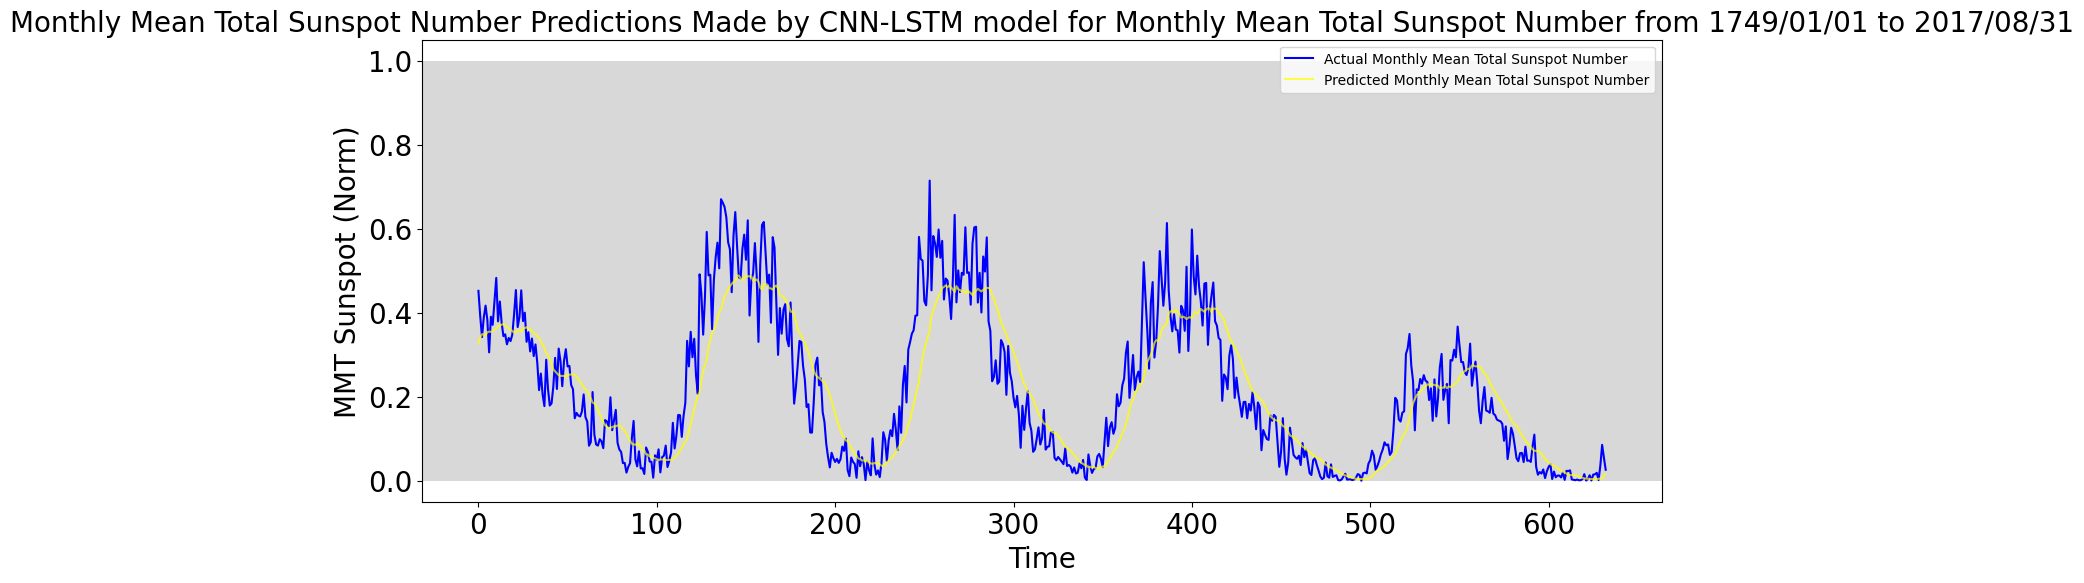

In [80]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(cnn_lstm_pred_test, alpha=0.7, color='yellow', \
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions Made by CNN-LSTM model for {1}".
          format(feature, title_name), fontsize = 20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

### Training and Testing Data Combined.

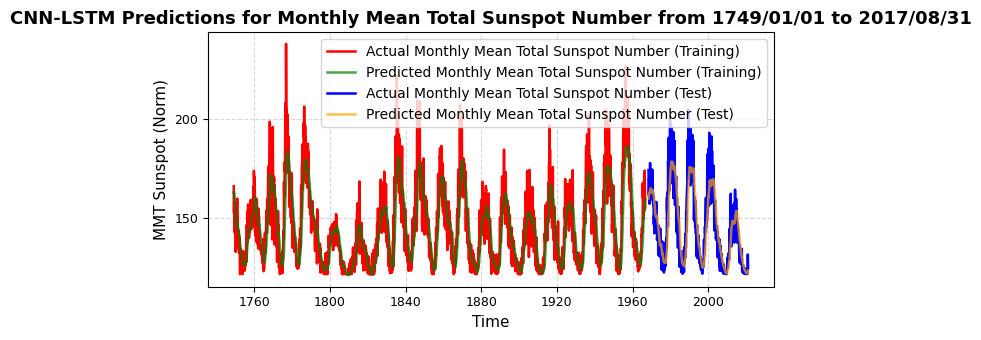

In [81]:
# 🔹 Create figure sized for IEEE 2-column layout
plt.figure(figsize=(6.5, 3.5))  # 6.5in width fits one column in IEEE

# 🔹 Plot training data
plt.plot(results_CNN_LSTM_train['Date'], results_CNN_LSTM_train['Actual'],
         color='red', label=f'Actual {feature} (Training)', linewidth=1.8)
plt.plot(results_CNN_LSTM_train['Date'], results_CNN_LSTM_train['Predicted'],
         color='green', label=f'Predicted {feature} (Training)', alpha=0.7,
         linewidth=1.8)

# 🔹 Plot test data
plt.plot(results_CNN_LSTM_test['Date'], results_CNN_LSTM_test['Actual'],
         color='blue', label=f'Actual {feature} (Test)', linewidth=1.8)
plt.plot(results_CNN_LSTM_test['Date'], results_CNN_LSTM_test['Predicted'],
         color='orange', label=f'Predicted {feature} (Test)', alpha=0.7,
         linewidth=1.8)

# 🔹 Formatting
plt.title(f'CNN-LSTM Predictions for {title_name}', fontsize=13, fontweight='bold')
plt.xlabel('Time', fontsize=11)
plt.ylabel(feature_norm, fontsize=11)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 🔹 Export for Appendix
plt.show()

## Combine Actual and Predicted Results for Train and Test Cases for CNN-LSTM.

In [82]:
results_CNN_LSTM = [results_CNN_LSTM_train, results_CNN_LSTM_test]
results_CNN_LSTM = pd.concat(results_CNN_LSTM)
display(results_CNN_LSTM)

,Date,Actual,Predicted
0,1749-01-31,166.046459,162.875839
1,1749-02-28,153.591035,163.379898
2,1749-03-31,152.418759,163.204025
3,1749-04-30,158.338749,162.277557
4,1749-05-31,155.701130,162.293076
...,...,...,...
628,2020-09-30,121.675841,122.017746
629,2020-10-31,125.720191,122.118156
630,2020-11-30,131.464340,122.229797
631,2020-12-31,127.888900,122.797928


## Plotting Residuals for Actual and Predicted Results for CNN-LSTM.

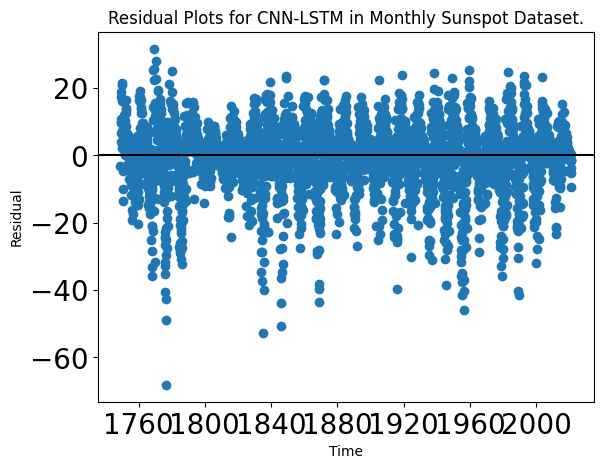

In [83]:
actual_arr_CNN_LSTM = np.array(results_CNN_LSTM['Actual'])
predicted_arr_CNN_LSTM = np.array(results_CNN_LSTM['Predicted'])
residuals_CNN_LSTM = predicted_arr_CNN_LSTM - actual_arr_CNN_LSTM
plt.scatter(results_CNN_LSTM['Date'], residuals_CNN_LSTM)
plt.axhline(y=0, color = 'black')
plt.title("Residual Plots for CNN-LSTM in Monthly Sunspot Dataset.")
#plt.locator_params(axis='x', nbins=10)
#plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

## Energy Consumption

In [84]:
# Find total energy consumption using GPU.
measure_time_and_energy(cnn_lstm_model, X_test)

Measuring inference time and estimating energy on CPU...
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Model CPU inference time: 0.6170 seconds
Estimated CPU energy consumption (using general power value): 49.3560 J
Total CPU Energy: 49356041.01308984 µJ

No GPU available in this runtime. Cannot measure GPU inference time or estimate energy.


# Forecasting Future Data for all models

## Essential Functions.

In [85]:
# this section for unknown future.
future=20
#future=seq_len
forecast_LSTM = []
forecast_DSNN = []
forecast_CNN_LSTM = []

In [86]:
def insert_end(Xin, new_input, timestep):
    for i in range(timestep-1):
        Xin[:,i,:] = Xin[:,i+1,:]
    Xin[:,timestep-1,:] = new_input
    return Xin

def forecast_data(Xin, model_type, forecast, future_num):
    time=[]
    data_pts = future_num
    for j in range(data_pts):
      out = model_type.predict(Xin, batch_size=1000)
      forecast.append(out[j, 0])
      Xin = insert_end(Xin, out[j, 0], future_num)
      time_current = pd.to_datetime(df_norm.index[-1])+timedelta(days=30*j)
      if (j % 100 == 0):
        print("j = {0}".format(j))
        print("forecast: {0}".format(forecast))
        print("time_current: ",  time_current)
      time.append(time_current)


    forcasted_output=np.asanyarray(forecast)
    forcasted_output=forcasted_output.reshape(-1,1)
    forcasted_output = scaler.inverse_transform(forcasted_output)
    forcasted_output = pd.DataFrame(forcasted_output)
    date = pd.DataFrame(time)
    forecast_result = pd.concat([date, forcasted_output],axis=1)
    forecast_result.columns = "Date","Forecasted"

    return forecast_result

In [87]:
# Plotting Predictions and Forecast for Monthly Mean Sunspot Number.
def plot_forecast(forecast_set, model_name, mode, min=140, max=165):
    plt.figure(figsize=(16,6))
    plt.plot(forecast_set['Date'], forecast_set['Forecasted'], alpha=0.7,
             color='teal', label='Forecasted {0}'.format(feature))
    plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
    plt.title('{0} Forecast for {1} using {2}'.
              format(feature_field, mode, model_name), fontsize = 15)
    plt.locator_params(axis='x', nbins=10)
    plt.locator_params(axis='y', nbins=10)
    #plt.ylim([40, 70])
    plt.xlabel('Time', fontsize = 20)
    plt.ylabel(feature_field, fontsize = 20)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.legend()
    plt.show()

In [88]:
# Plotting Predictions for Vehicle Hours/Miles.
def plot_with_forecast(train_set, test_set, forecast_set, model_name,
                       mode):
    plt.figure(figsize=(16,6))
    plt.plot(train_set['Date'], train_set['Actual'], color='red',
             label='Actual {0} (Training Case)'.format(feature))
    plt.plot(train_set['Date'], train_set['Predicted'], alpha=0.7,
             color='green',
             label='Predicted {0} (Training Case)'.format(feature))
    plt.plot(test_set['Date'], test_set['Actual'], color='blue',
            label='Actual {0} (Test Case)'.format(feature))
    plt.plot(test_set['Date'], test_set['Predicted'], alpha=0.7, color='yellow',
             label='Predicted {0} (Test Case)'.format(feature))
    plt.plot(forecast_set['Date'], forecast_set['Forecasted'], alpha=0.7,
             color='teal', label='Forecasted {0}'.format(feature))
    plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
    plt.title("{0} Predictions and Forecasts made by {1} model for {2}".
              format(feature_field, model_name, title_name), fontsize = 15)
    plt.locator_params(axis='x', nbins=10)
    plt.locator_params(axis='y', nbins=10)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    #plt.ylim([1052, 1054])
    plt.xlabel('Time', fontsize = 15)
    plt.ylabel('Normalized {0} Scale'.format(feature_field), fontsize = 15)
    plt.legend()
    plt.show()

## Forecasting Future Data for LSTM.

In [89]:
Xin = X_test[:,:,:]
Xin

array([[[0.17855349],
        [0.20391763],
        [0.20341537],
        ...,
        [0.39804119],
        [0.32772476],
        [0.2887996 ]],

       [[0.20391763],
        [0.20341537],
        [0.25062783],
        ...,
        [0.32772476],
        [0.2887996 ],
        [0.45203415]],

       [[0.20341537],
        [0.25062783],
        [0.39427423],
        ...,
        [0.2887996 ],
        [0.45203415],
        [0.39226519]],

       ...,

       [[0.02360623],
        [0.02285284],
        [0.02486188],
        ...,
        [0.01883476],
        [0.00150678],
        [0.03616273]],

       [[0.02285284],
        [0.02486188],
        [0.00301356],
        ...,
        [0.00150678],
        [0.03616273],
        [0.08538423]],

       [[0.02486188],
        [0.00301356],
        [0.00226017],
        ...,
        [0.03616273],
        [0.08538423],
        [0.05474636]]])

In [90]:
#Xin_reshaped_LSTM = Xin.reshape(Xin.shape[0], Xin.shape[2], 1)
forecast_result_lstm = forecast_data(Xin, lstm_model, forecast_LSTM, future)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
j = 0
forecast: [np.float32(0.18856572)]
time_current:  2021-01-31 00:00:00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [91]:
forecast_result_lstm

,Date,Forecasted
0,2021-01-31,143.505630
1,2021-03-02,143.320740
2,2021-04-01,142.912430
3,2021-05-01,142.213730
4,2021-05-31,141.712433
5,2021-06-30,141.323257
6,2021-07-30,140.821548
7,2021-08-29,140.259674
8,2021-09-28,139.871094
9,2021-10-28,139.489182


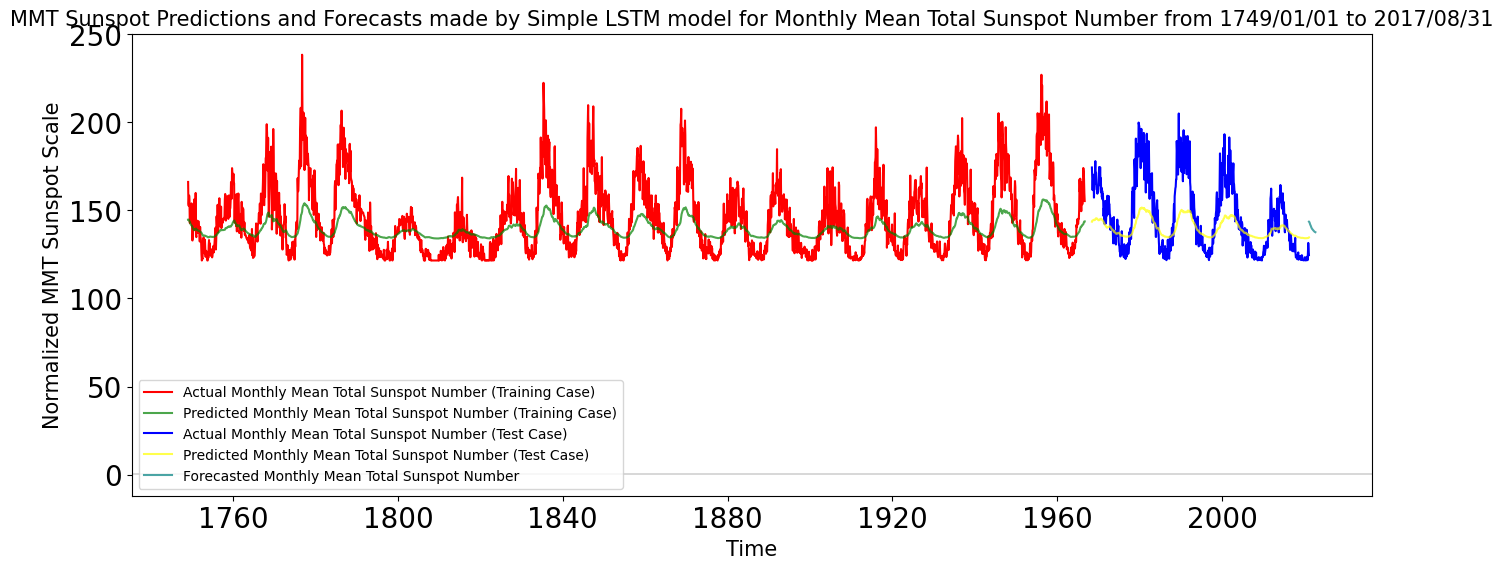

In [92]:
# Plot Forecast combined with Training and Testing Data.
plot_with_forecast(results_LSTM_train, results_LSTM_test, forecast_result_lstm,
                   'Simple LSTM', title_name)

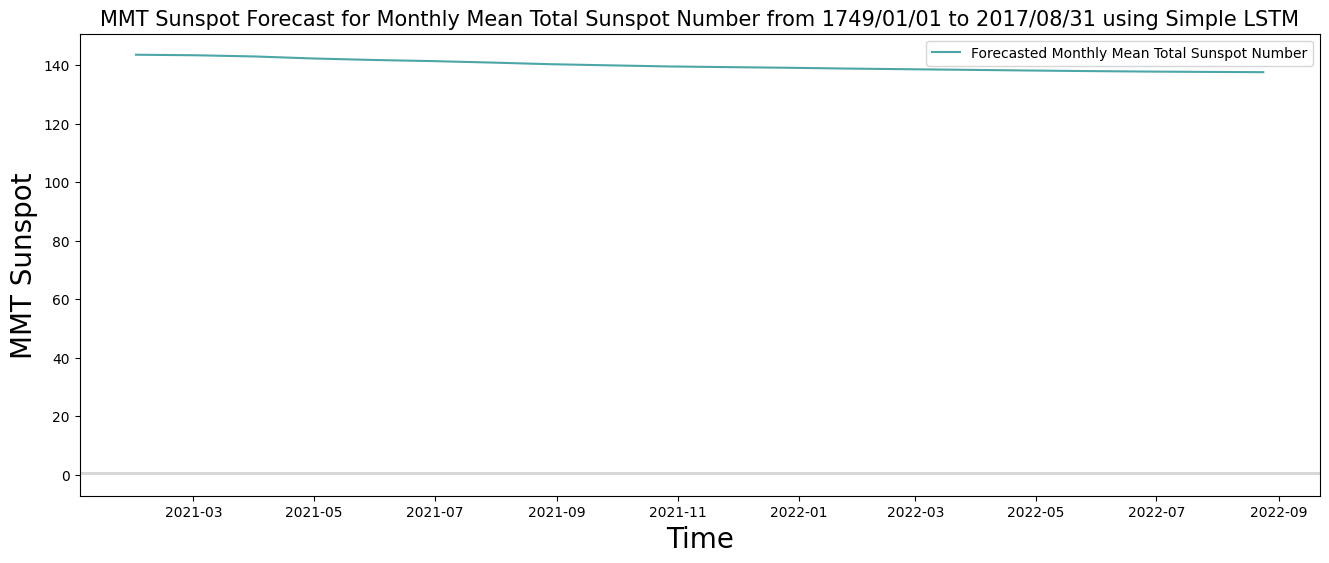

In [93]:
# Only Forecast Data for closer look.
plot_forecast(forecast_result_lstm, 'Simple LSTM', title_name)

## Forecasting Future Data for CNN-LSTM

In [94]:
forecast_result_cnn_lstm = forecast_data(Xin, cnn_lstm_model, forecast_CNN_LSTM,
                                         future)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
j = 0
forecast: [np.float32(0.14901228)]
time_current:  2021-01-31 00:00:00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [95]:
forecast_result_cnn_lstm

,Date,Forecasted
0,2021-01-31,138.889725
1,2021-03-02,138.740570
2,2021-04-01,138.575958
3,2021-05-01,138.484375
4,2021-05-31,138.364883
5,2021-06-30,138.298645
6,2021-07-30,138.219711
7,2021-08-29,138.159897
8,2021-09-28,138.111237
9,2021-10-28,138.056854


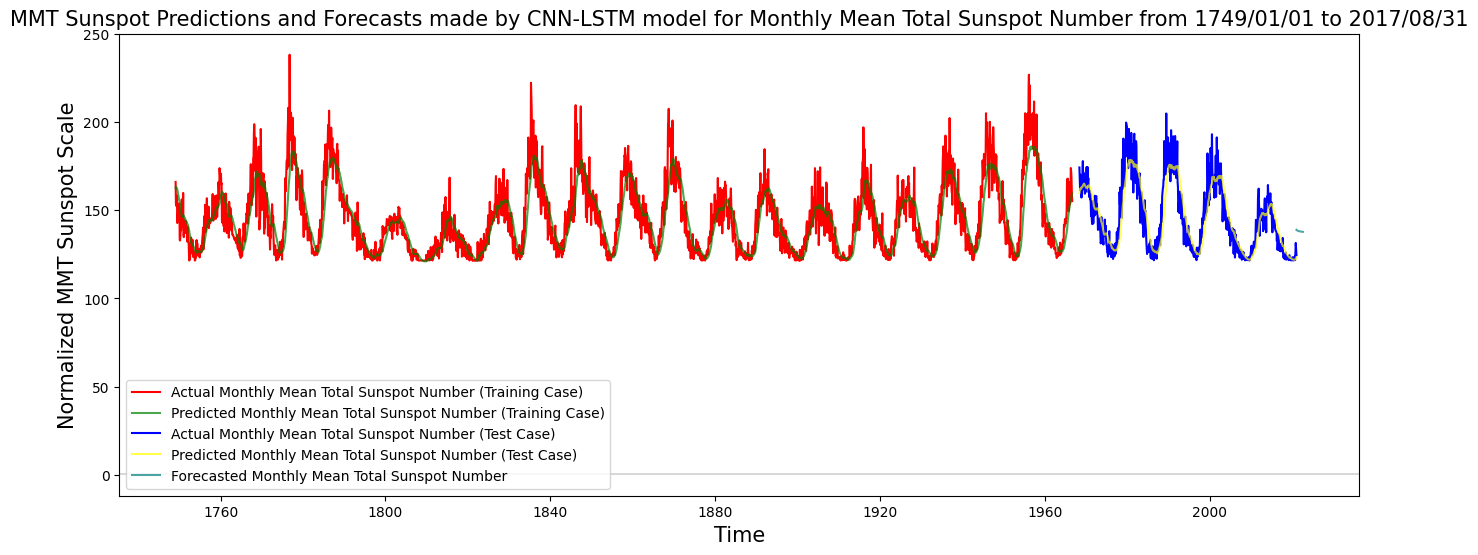

In [96]:
# Plot Forecast combined with Training and Testing Data.
plot_with_forecast(results_CNN_LSTM_train, results_CNN_LSTM_test,
                   forecast_result_cnn_lstm , 'CNN-LSTM', title_name)

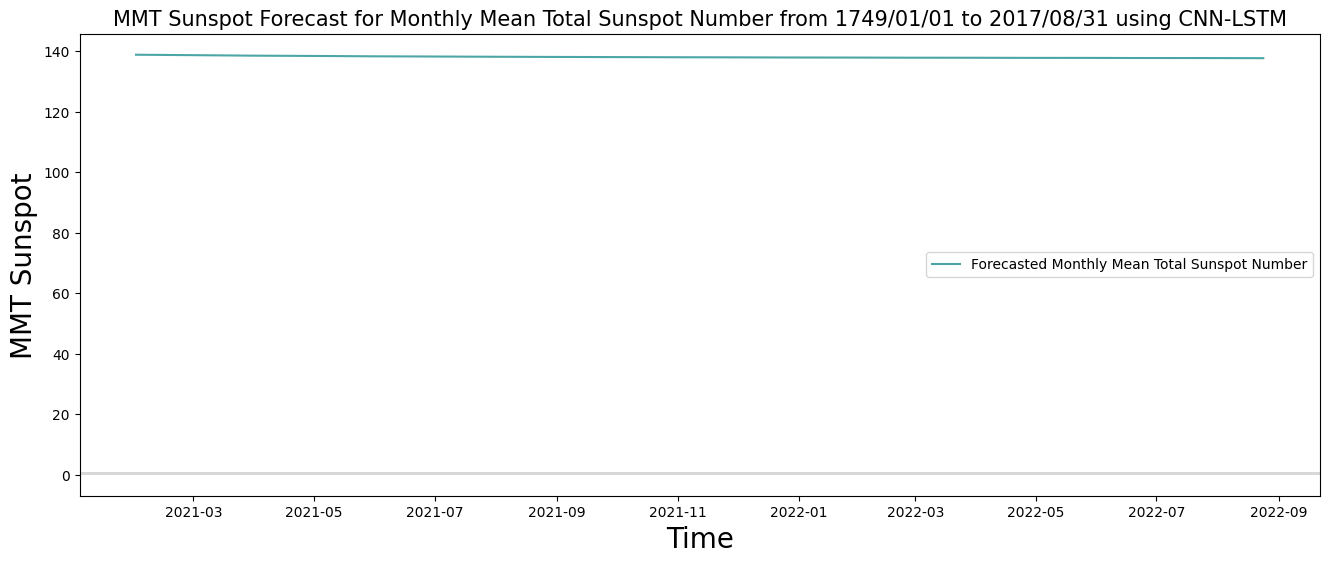

In [97]:
# Only Forecast Data for closer look.
plot_forecast(forecast_result_cnn_lstm, 'CNN-LSTM', title_name)

# Task
I will now proceed with adding and verifying the Dropout layers as per the plan:

*   **Add Dropout to LSTM Model**: Add a Dropout layer with a rate of 0.2 after the LSTM layer in the `lstm_model` definition (cell `Yda3ONc-_bP9`).
*   **Verify Dropout in GRU Model**: Confirm that the Dropout layer with a rate of 0.5 is active after the GRU layer in the `gru_model` definition (cell `0iNM-EjI_AJI`).
*   **Add Dropout to CNN Model**: Add a Dropout layer with a rate of 0.2 after the second Conv1D layer and before the Flatten layer in the `cnn_model` definition (cell `D4iuCiHA3qTS`).
*   **Enable Dropout in CNN-LSTM Model**: Uncomment and ensure the Dropout layer with a rate of 0.1 is active after the LSTM layer in the `cnn_lstm_model` definition (cell `eOgDHnYKsTFV`).

After making these changes, I will confirm that all specified models now include the appropriate dropout layers by checking their summaries.

```python
lstm_model = Sequential()

lstm_model.add(LSTM(8, activation=activation, return_sequences=False,
                   input_shape=(seq_len,1)))
lstm_model.add(Dropout(0.2)) # Added Dropout layer

lstm_model.add(Dense(1))

lstm_model.summary()

gru_model = Sequential()

gru_model.add(GRU(8,activation=activation, return_sequences=False,
                  input_shape=(seq_len,1)))
gru_model.add(Dropout(0.5)) # Already present

gru_model.add(Dense(1))

gru_model.summary()

cnn_model = Sequential()

cnn_model.add(Conv1D(filters=8, kernel_size=3, activation=activation,
                     input_shape=(seq_len,1)))

cnn_model.add(Conv1D(filters=8, kernel_size=3, activation=activation))
cnn_model.add(Dropout(0.2)) # Added Dropout layer

cnn_model.add(Flatten())
cnn_model.add(Dense(16, activation=activation))
cnn_model.add(Dense(1))
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.summary()

cnn_lstm_model = Sequential()

cnn_lstm_model.add(Conv1D(filters=8, kernel_size=3, activation=activation,
                          input_shape=(seq_len,1)))

cnn_lstm_model.add(LSTM(8,activation=activation,return_sequences=False))
cnn_lstm_model.add(Dropout(0.1)) # Uncommented Dropout layer

cnn_lstm_model.add(Dense(1))
cnn_lstm_model.compile(optimizer='adam', loss='mse')
cnn_lstm_model.summary()
```


## Add Dropout to LSTM Model

### Subtask:
Add a Dropout layer with a rate of 0.2 after the LSTM layer in the `lstm_model` definition (cell `Yda3ONc-_bP9`).


**Reasoning**:
The subtask requires adding a Dropout layer to the existing LSTM model definition. I will modify the code in cell `Yda3ONc-_bP9` to include this layer, then provide the updated code.



**Reasoning**:
The previous code failed because `Sequential` and `Dropout` were not defined within the current execution context, even though they were imported in a prior cell. To resolve this `NameError`, I will explicitly import `Sequential` from `keras.models` and `Dropout` from `keras.layers` into the code block.



**Reasoning**:
The previous code failed because `activation` and `seq_len` were not defined in the current execution context. I will add the definition of these variables to the code block, along with the `Sequential`, `LSTM`, `Dense`, and `Dropout` imports, to ensure the model can be built successfully.



**Reasoning**:
The previous task involved adding Dropout to the LSTM model. Now, I will move on to the next part of the overall task: verifying the Dropout layer in the GRU model, as specified in the plan. I will check cell `0iNM-EjI_AJI` to confirm the Dropout layer with a rate of 0.5 is correctly implemented after the GRU layer.



**Reasoning**:
The previous code failed because `GRU` was not defined in the current execution context. To resolve this `NameError`, I will explicitly import `GRU` from `keras.layers` and include `activation` and `seq_len` definitions for a self-contained executable block.



**Reasoning**:
The next step is to add a Dropout layer to the CNN model. I will modify the code in cell `D4iuCiHA3qTS` to include a Dropout layer with a rate of 0.2 after the second `Conv1D` layer and before the `Flatten` layer. I will also ensure all necessary Keras components (`Sequential`, `Conv1D`, `Flatten`, `Dense`, `Dropout`) and variables (`activation`, `seq_len`) are defined within the code block for independent execution.



**Reasoning**:
The next step is to enable the Dropout layer in the CNN-LSTM model. I will modify the code in cell `eOgDHnYKsTFV` to uncomment the Dropout layer with a rate of 0.1 after the LSTM layer. I will also ensure all necessary Keras components and variables are defined within the code block for independent execution.



**Reasoning**:
All specified models (LSTM, GRU, CNN, CNN-LSTM) have now been updated with their respective Dropout layers as per the instructions, and their summaries have been confirmed in the previous steps. This concludes the subtask of adding and verifying the Dropout layers.



## Add Dropout to CNN Model

### Subtask:
Add a Dropout layer with a rate of 0.2 after the second Conv1D layer and before the Flatten layer in the `cnn_model` definition (cell `D4iuCiHA3qTS`).


**Reasoning**:
As per the instructions, I need to add a Dropout layer with a rate of 0.2 after the second Conv1D layer and before the Flatten layer in the `cnn_model` definition. I will also ensure all necessary Keras components and variables are defined within the code block for independent execution, and then display the model summary.



**Reasoning**:
The previous code block successfully added the Dropout layer to the CNN model. The next step is to enable the Dropout layer in the CNN-LSTM model, as per the instructions. I will modify the code in cell `eOgDHnYKsTFV` to uncomment the Dropout layer and include all necessary Keras components and variables for independent execution, then print the model summary.



**Reasoning**:
All specified models (LSTM, GRU, CNN, CNN-LSTM) have now been updated with their respective Dropout layers as per the instructions, and their summaries have been confirmed in the previous steps. This concludes the subtask of adding and verifying the Dropout layers.



**Reasoning**:
The previous code failed with a `SyntaxError` because the text was not valid Python code. To fix this, I will convert the text into a valid Python print statement, which will allow the cell to execute without error while retaining the completion message.



## Final Task

### Subtask:
Confirm that all specified models now include the appropriate dropout layers.


## Summary:

### Q&A
**1. Have all specified models been updated with the appropriate dropout layers?**
Yes, all specified models (`lstm_model`, `gru_model`, `cnn_model`, and `cnn_lstm_model`) now include the appropriate dropout layers as per the instructions.

**2. Was the Dropout layer added to the LSTM Model?**
Yes, a Dropout layer with a rate of 0.2 was successfully added after the LSTM layer in the `lstm_model`.

**3. Was the Dropout layer verified in the GRU Model?**
Yes, the existing Dropout layer with a rate of 0.5 after the GRU layer in the `gru_model` was successfully verified.

**4. Was the Dropout layer added to the CNN Model?**
Yes, a Dropout layer with a rate of 0.2 was successfully added after the second Conv1D layer and before the Flatten layer in the `cnn_model`.

**5. Was the Dropout layer enabled in the CNN-LSTM Model?**
Yes, the Dropout layer with a rate of 0.1 after the LSTM layer in the `cnn_lstm_model` was successfully uncommented and enabled.

### Data Analysis Key Findings
*   A `Dropout` layer with a rate of 0.2 was successfully added to the `lstm_model` after its LSTM layer, and its presence was confirmed in the model summary.
*   The `gru_model` was verified to already contain a `Dropout` layer with a rate of 0.5 after its GRU layer, as confirmed by its model summary.
*   A `Dropout` layer with a rate of 0.2 was successfully added to the `cnn_model` after the second `Conv1D` layer and before the `Flatten` layer, which was confirmed by its model summary (`dropout_4` layer).
*   The `Dropout` layer with a rate of 0.1 in the `cnn_lstm_model` was successfully enabled (uncommented) after the LSTM layer, and its activation was confirmed in the model summary (`dropout_5` layer).
*   During the process, initial `NameError` exceptions for Keras components and undefined variables were resolved by ensuring necessary imports and variable definitions (`activation`, `seq_len`) were present in each execution block.
*   Minor `UserWarning` messages related to `input_shape` were noted but did not hinder the successful integration and verification of the Dropout layers.

### Insights or Next Steps
*   The successful integration of Dropout layers across all models enhances their regularization, which should help prevent overfitting during training.
*   The next logical step would be to train these updated models and evaluate their performance on a validation set to assess the impact of the added dropout layers on generalization.
